# Parametrized gates and gradients — differentiating a quantum circuit four ways

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 11 — Variational quantum circuits*

## 1. Introduction and motivation

Everything so far in these notes has been a *simulation of a fixed physical process*: a Hamiltonian was given, a circuit
was given, and we computed what the state does. This chapter inverts the question. We fix a **family** of circuits
$U(\boldsymbol\theta)$ controlled by a vector of angles $\boldsymbol\theta\in\mathbb R^{n}$, define a number

$$C(\boldsymbol\theta)=\langle\psi(\boldsymbol\theta)\vert\,\hat O\,\vert\psi(\boldsymbol\theta)\rangle,
  \qquad \vert\psi(\boldsymbol\theta)\rangle=U(\boldsymbol\theta)\vert 0\rangle^{\otimes N},$$

that says how good the resulting state is, and ask a classical computer to **minimise** it. That is a *variational
quantum algorithm*: a hybrid loop in which a quantum device (or, here, a simulator) evaluates the cost and a classical
optimiser proposes the next angles.

![The variational loop: a parametrized circuit prepares a state, a measurement returns the cost, a classical optimiser returns new angles](figures/vqa_loop.svg)\
**Figure 1.** The variational loop. The circuit $U(\boldsymbol\theta)$ acts on $N$ qubits initialised in
$\vert0\rangle$, the measurement of $\hat O$ turns the prepared state into the single number $C(\boldsymbol\theta)$,
and the classical optimiser uses that number and its gradient to choose the angles of the next round. In this
notebook the quantum box is our simulator.

**Why people study this.** A quantum computer running Shor's or the phase-estimation algorithm on a problem of practical
size needs quantum error correction and far more physical qubits than any existing device. The devices that exist now have tens to hundreds of noisy qubits and
circuits that decohere after a few tens of layers. A variational algorithm is designed for exactly that regime: the
quantum part is a *short* circuit, everything expensive and iterative is pushed onto the classical optimiser, and the
free angles can absorb part of the hardware's systematic errors. The first experiment of this kind solved a two-qubit
chemistry problem on a photonic chip (Peruzzo *et al.*, 2014); the framework was formalised shortly afterwards (McClean
*et al.*, 2016) and scaled to six superconducting qubits (Kandala *et al.*, 2017). The same loop is behind the
variational quantum eigensolver, quantum machine learning, and variational state compression.

**What is simulated here.** Nothing in this notebook is a quantum computer: the states are the rank-$N$ tensors of our
einsum engine, and every "measured" expectation value is computed exactly unless we deliberately sample from it. This
lets us ask questions that no experiment can answer — what is the *exact* gradient, how large is the
estimator variance, how flat is the landscape at $N=10$ — and it lets us test the gradient formulas that hardware is
forced to use against the exact answer that only a simulator knows.

**The problem this notebook solves.** Every optimiser in the next notebook needs a gradient
$\partial C/\partial\theta_k$. On a simulator we can call `jax.grad`. On hardware that is impossible: there is no
access to the amplitudes, only to measurement statistics. So four different methods are in use, and they differ by orders
of magnitude in accuracy, in the number of circuit executions, and in memory. We derive all four, implement all four,
and measure them against each other.

**Road map.**

1. **Parametrized gates** as exponentials of Pauli operators: single-qubit rotations, two-qubit rotations, controlled
   rotations, and the eigenvalue structure that will decide the gradient rules (Section 3).
2. **Ansätze**: the hardware-efficient ansatz with its parameter count derived, and a problem-inspired
   Hamiltonian-variational ansatz built from a Trotterised adiabatic path (Section 4).
3. **Cost functions**: the energy of a local Hamiltonian, and state-preparation infidelity; global versus local costs
   (Section 5).
4. **The landscape along one angle** is a pure sinusoid $a+b\cos(\theta-c)$ when the angle enters a single gate
   $e^{-i\theta P/2}$ with $P^2=\mathbb 1$ — derived from the two eigenvalues $\pm\tfrac12$ of the generator, then
   measured by fitting a scan (Section 6).
5. **Gradients four ways**: finite differences with the truncation/round-off trade-off and the optimal step (Section 7);
   the parameter-shift rule, derived, plus the four-term rule that controlled rotations need (Section 8); SPSA, with its
   bias and variance derived and measured (Section 9); reverse-mode automatic differentiation, explained as forward
   storage plus backward adjoint gates, with a hand-written adjoint differentiator checked against `jax.grad`
   (Section 10).
6. **Cost comparison** of all four versus the number of parameters: circuit evaluations, wall time, compiled memory
   (Section 11).
7. **Shot noise**: the variance of a parameter-shift gradient estimated from finite samples, and a fair comparison with
   SPSA at equal shot budget (Section 12).
8. **Barren plateaus**: the variance of one gradient component over random angles, measured as a function of $N$ for a
   global and a local cost, with the exponent fitted (Section 13).

### What you will learn

*Physics*

* why a rotation generated by a Pauli operator, with its angle appearing in that one gate only, makes the expectation
  value of any observable a sinusoid in the angle, and what changes when the generator has more than two distinct
  eigenvalues or the angle is shared by several gates;
* what an ansatz is, why "hardware-efficient" and "problem-inspired" are opposite design philosophies, and how the
  Hamiltonian-variational ansatz descends from adiabatic evolution;
* why a cost built from a *global* observable becomes exponentially flat with system size while a *local* one need not —
  the barren-plateau phenomenon, measured here rather than quoted.

*Numerical methods*

* the truncation-versus-round-off trade-off of finite differences and the resulting optimal step
  $h_\star\propto\varepsilon_{\text{mach}}^{1/3}$, in double and in single precision;
* the parameter-shift rule as an exact identity with no truncation error, its arbitrary-shift form, and its four-term
  generalisation;
* SPSA: unbiasedness up to an $O(c^2)$ term whose size grows with the number of parameters, variance
  $\lVert\nabla C\rVert^2-(\partial_kC)^2$, and its behaviour at equal shot budget;
* reverse-mode automatic differentiation on a circuit: one forward pass, one backward pass with adjoint gates, a cost of
  a few forward passes whatever the number of parameters, and the memory it costs;
* the shot-noise variance of every estimator, derived and compared with sampled data;

*Implementation practice*

* `jax.grad` straight through an einsum simulator, and a hand-written adjoint differentiator that reproduces it;
* `jax.vmap` to batch all $2n$ shifted circuits of a parameter-shift gradient into one call, and to batch hundreds of
  random parameter draws for a variance study;
* benchmarking: compile time separated from run time, wall times compared with the time of one forward pass, evaluation
  counts reported next to wall times, and compiled-memory footprints read off the XLA memory analysis;
* statistical checkpoints that come with a wrong control, i.e. a plausible but incorrect prediction that the same test
  must reject.

### Prerequisites

* [09 — quantum gates and circuits](../ch04_digital_quantum_circuits/09_quantum_gates_and_circuits.ipynb): gates as
  unitaries, `apply_gate`, circuits as gate lists, rotations $R_x,R_y,R_z$;
* [05 — matrix-free operators](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb) and
  [06 — states, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb):
  states as rank-$N$ tensors, expectation values of local operators;
* [08 — measurements](../ch03_matrix_free_engine/08_measurements.ipynb): the Born rule and sampling bit strings, needed
  for the shot-noise section;
* [11 — Hamiltonians and ground states](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb):
  Hamiltonians as lists of local terms, the exact ground energy from Lanczos;
* [01 — JAX](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, `grad`, PRNG keys.

**What comes next.** [41 — optimisers](../ch11_variational_quantum_circuits/41_optimizers.ipynb) takes the gradients
built here and feeds them to gradient descent, momentum, Adam, SPSA and the quantum natural gradient, with `lax.scan`
training loops and statistics over random initialisations;
[42 — the variational quantum eigensolver](../ch11_variational_quantum_circuits/42_variational_quantum_eigensolver.ipynb)
then runs the full algorithm on spin chains and compares the optimised state with the exact ground state.

**Conventions and sizes.** Qubit $q$ is tensor axis $q$; $\vert0\rangle$ is the $+1$ eigenstate of $Z$; Hamiltonians are
written in the Pauli convention $H=\sum J\,ZZ+\sum h\,X$. All states are pure state vectors; the largest registers
are $N=10$ in the barren-plateau scan and $N=12$ in one timing measurement.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and notebook helpers

We need the rotation gates and the two-qubit Pauli rotations, `apply_gate`, the hardware-efficient ansatz with its
parameter count, the Hamiltonian machinery (`heisenberg_terms`, `energy`, `dense_hamiltonian`, `lanczos_ground_state`),
`sample_bitstrings` for the shot-noise section, and — as the reference implementations we must reproduce and then
outperform — the engine's `parameter_shift_grad` and `spsa_grad`.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
P1 = jnp.array([[0, 0], [0, 1]], dtype=CDTYPE)  # projector |1><1|
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)
def rx(theta):
    """Rotation about x:  Rx(theta) = exp(-i theta X/2) = cos(theta/2) 1 - i sin(theta/2) X.

    Derivation: for any operator with P^2 = 1 the exponential series splits into even/odd
    parts,  exp(-i a P) = cos(a) 1 - i sin(a) P.   Here a = theta/2.
    `theta` may be a traced JAX scalar, so the gate is differentiable (jax.grad) and jit-able.
    """
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -1j * s], [-1j * s, c]], dtype=CDTYPE)

def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)

def rz(theta):
    """Rotation about z:  Rz(theta) = exp(-i theta Z/2) = diag(e^{-i theta/2}, e^{+i theta/2})."""
    e = jnp.exp(-0.5j * theta)
    return jnp.array([[e, 0], [0, jnp.conj(e)]], dtype=CDTYPE)

def rpp(theta, PP):
    """Two-qubit Pauli rotation  exp(-i theta PP/2)  for any product PP of two Pauli matrices (XX, YY, ZZ, XY, ...).

    Because (P x Q)^2 = 1 the same closed form as for single-qubit rotations holds:
        exp(-i theta PP/2) = cos(theta/2) 1_4 - i sin(theta/2) PP.
    These are the native entangling gates of trapped ions (XX) and the building blocks
    of Trotterised spin-chain evolution.
    """
    return jnp.cos(theta / 2) * jnp.eye(4, dtype=CDTYPE) - 1j * jnp.sin(theta / 2) * PP

def rxx(theta):
    """exp(-i theta X(x)X / 2)."""
    return rpp(theta, XX)

def ryy(theta):
    """exp(-i theta Y(x)Y / 2)."""
    return rpp(theta, YY)

def rzz(theta):
    """exp(-i theta Z(x)Z / 2)  -- diagonal: diag(e^{-i t/2}, e^{+i t/2}, e^{+i t/2}, e^{-i t/2})."""
    return rpp(theta, ZZ)

def controlled(U):
    """Controlled-U = |0><0| (x) 1 + |1><1| (x) U  as a 4x4 block matrix (control = first qubit)."""
    return jnp.block([[jnp.eye(2, dtype=CDTYPE), jnp.zeros((2, 2), CDTYPE)],
                      [jnp.zeros((2, 2), CDTYPE), U]])


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def expect_local(psi, O, qubits):
    """<psi| O_qubits |psi> for a k-local operator O (2^k x 2^k matrix).

    MATH   <O> = Tr(rho_A O)  with A = `qubits`: a local observable only sees the local state.
    Cost O(2^N) for the RDM + O(4^k) for the small trace.  One RDM serves ALL observables on A
    (e.g. <X>,<Y>,<Z> from a single 2x2 matrix).
    """
    return jnp.real(jnp.trace(rdm(psi, qubits) @ jnp.asarray(O, dtype=CDTYPE)))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def fidelity_pure(psi, phi):
    """F = |<psi|phi>|^2 between two pure states."""
    return jnp.abs(jnp.vdot(psi, phi)) ** 2


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def sample_bitstrings(key, psi, shots, bases=None):
    """Sample `shots` outcomes of measuring ALL qubits (no collapse bookkeeping needed).

    MATH   p(s) = |psi[s]|^2 ; optional per-qubit bases string like 'XZY' rotates first.
    IMPLEMENTATION   `jax.random.categorical` draws flat indices from log-probabilities; the bits are
    unpacked with shifts:  s_q = (i >> (N-1-q)) & 1   (qubit 0 = most significant bit).
    Returns an int array of shape (shots, N).
    """
    N = psi.ndim
    if bases is not None:
        for q, b in enumerate(bases):
            psi = apply_gate(psi, _BASIS_ROT[b], [q])
    logp = jnp.log(jnp.clip(jnp.abs(psi.reshape(-1)) ** 2, 1e-300, None))
    idx = jax.random.categorical(key, logp, shape=(shots,))
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def energy(terms, psi):
    """<psi|H|psi> = Re <psi | (H psi)>."""
    return jnp.real(jnp.vdot(psi, apply_hamiltonian(terms, psi)))

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
def hea_num_params(N, layers):
    """Number of angles of `hardware_efficient_ansatz`: (layers+1) rotation blocks x N qubits x 2 angles."""
    return 2 * N * (layers + 1)

def hardware_efficient_ansatz(theta, N, layers, entangler=CZ, periodic=False):
    """Hardware-efficient ansatz
        |psi(theta)> = R(theta_L) * prod_{l<L} [ ENT * R(theta_l) ] |0...0>,   R = prod_q Rz(.) Ry(.),
    ENT = a chain of CZ (or any 2-qubit gate).  `theta` is a flat vector of length 2N(L+1).
    The function is a pure map theta -> state, hence jit-able and differentiable end to end."""
    theta = theta.reshape(layers + 1, N, 2)
    psi = zero_state(N)
    for l in range(layers + 1):
        for q in range(N):
            psi = apply_gate(psi, ry(theta[l, q, 0]), [q])
            psi = apply_gate(psi, rz(theta[l, q, 1]), [q])
        if l < layers:
            for q in range(N - 1):
                psi = apply_gate(psi, entangler, [q, q + 1])
            if periodic and N > 2:
                psi = apply_gate(psi, entangler, [N - 1, 0])
    return psi

def parameter_shift_grad(f, theta, shift=jnp.pi / 2):
    """Parameter-shift rule: for gates exp(-i theta_k P/2) with P^2 = 1 the cost is a sinusoid in theta_k,
        f = a + b cos(theta_k) + c sin(theta_k),   so for any shift s with sin(s) != 0
        d f / d theta_k = [ f(theta + s e_k) - f(theta - s e_k) ] / (2 sin s)          (EXACT, not finite differences)
    and the default s = pi/2 gives the familiar [ f(+pi/2) - f(-pi/2) ] / 2.
    -- the gradient a real quantum computer can measure: 2 circuit evaluations per parameter.
    JAX: vmap over the unit vectors e_k evaluates all shifted circuits in one batched call."""
    eye = jnp.eye(theta.size).reshape((theta.size,) + theta.shape)
    denom = 2 * jnp.sin(shift)
    return jax.vmap(lambda e: (f(theta + shift * e) - f(theta - shift * e)) / denom)(eye).reshape(theta.shape)

def spsa_grad(key, f, theta, c=0.1):
    """SPSA gradient estimate (Spall 1992): perturb ALL parameters at once along a random +-1 direction Delta,
        g = [f(theta + c Delta) - f(theta - c Delta)] / (2c) * Delta        (Delta_k^{-1} = Delta_k)
    Two evaluations regardless of the number of parameters; unbiased up to O(c^2); noisy but cheap --
    the method of choice for shot-noise-limited / stochastic cost functions."""
    delta = jax.random.rademacher(key, theta.shape).astype(theta.dtype)
    return (f(theta + c * delta) - f(theta - c * delta)) / (2 * c) * delta


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers used throughout this notebook
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def timed(fn, *args, repeat=3):
    """Wall time of a compiled JAX call: one warm-up (compilation), then `repeat` timed runs.

    IMPLEMENTATION  `block_until_ready` forces JAX's asynchronous dispatch to finish before the clock is read;
                    without it we would time the *submission* of the work, not the work.
    Returns (value, compile_time, best_run_time).
    """
    t0 = time.perf_counter()
    out = jax.block_until_ready(fn(*args))
    t_compile = time.perf_counter() - t0
    best = np.inf
    for _ in range(repeat):
        t0 = time.perf_counter()
        jax.block_until_ready(fn(*args))
        best = min(best, time.perf_counter() - t0)
    return out, t_compile, best


def compiled_bytes(fn, *args):
    """Temporary (scratch) memory that XLA allocates for one call of `jax.jit(fn)`, in bytes.

    This is read from the compiled executable's memory analysis, not estimated: it is the size of the buffers XLA
    reserves for intermediate values, which is exactly the quantity that distinguishes a forward pass from a
    reverse-mode gradient (Section 10).
    """
    return int(jax.jit(fn).lower(*args).compile().memory_analysis().temp_size_in_bytes)

## 3. Parametrized gates as exponentials of Pauli operators

### 3.1 One qubit

A gate is a unitary, and every unitary is the exponential of $-i$ times a Hermitian operator. In a laboratory that
Hermitian operator is a **Hamiltonian applied for a controlled time**: a resonant microwave pulse on a superconducting
qubit generates $H=\tfrac{\Omega}{2}(\cos\phi\,X+\sin\phi\,Y)$, and the rotation angle is $\theta=\Omega t$. This is why
the natural parameter of a quantum gate is an **angle**, and why the gates of a variational circuit are

$$U_k(\theta_k)=e^{-i\theta_k P_k/2},\qquad P_k\ \text{a Pauli operator (or a product of Paulis)}. \tag{1}$$

The factor $\tfrac12$ is convention; it makes $\theta=2\pi$ the identity up to a sign for a single Pauli.

Every Pauli operator satisfies $P^2=\mathbb 1$. Split the exponential series into even and odd powers:

$$\begin{aligned}
e^{-i\theta P/2}&=\sum_{m=0}^{\infty}\frac{1}{m!}\Bigl(-\frac{i\theta}{2}\Bigr)^{m}P^{m}
 =\sum_{m\ \text{even}}\frac{(-i\theta/2)^m}{m!}\mathbb 1+\sum_{m\ \text{odd}}\frac{(-i\theta/2)^m}{m!}P\\
&=\cos\frac{\theta}{2}\,\mathbb 1-i\sin\frac{\theta}{2}\,P .
\end{aligned}\tag{2}$$

Equation (2) covers all single-qubit rotations. With $P=X,Y,Z$ it gives $R_x,R_y,R_z$; the engine implements
exactly this closed form, which is why the gates are cheap *and* differentiable (the angle enters only through
$\cos$ and $\sin$, which JAX differentiates without any special case).

### 3.2 Two qubits

The same identity works for any operator that squares to the identity, in particular for a **product** of two Paulis:
$(X\otimes X)^2=X^2\otimes X^2=\mathbb 1$. So

$$R_{PP}(\theta)=e^{-i\theta\,P\otimes P/2}=\cos\frac{\theta}{2}\,\mathbb 1_4-i\sin\frac{\theta}{2}\,P\otimes P ,\tag{3}$$

which is `rxx`, `ryy`, `rzz` in the engine. $R_{XX}$ is the native entangling gate of trapped-ion processors, and $R_{ZZ}$ is the elementary factor of a Trotterised Ising evolution (see
[12 — TEBD](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb)).

### 3.3 Controlled rotations and their three-eigenvalue generator

A controlled rotation applies $R_P(\theta)$ to a target qubit only when the control is $\vert1\rangle$:

$$CR_P(\theta)=\vert0\rangle\langle0\vert\otimes\mathbb 1+\vert1\rangle\langle1\vert\otimes e^{-i\theta P/2}
  =\exp\bigl(-i\theta\,G\bigr),\qquad G=\vert1\rangle\langle1\vert\otimes\frac{P}{2}. \tag{4}$$

The second equality holds because $G$ annihilates the whole $\vert0\rangle$-control block, so the exponential is the
identity there. The generator $G$ is **not** proportional to a Pauli operator and does **not** square to the identity:
its eigenvalues are $\{0,0,+\tfrac12,-\tfrac12\}$ — three distinct values instead of two. Section 8 shows that this
single fact changes the gradient rule.

The code below builds each gate two ways: from the engine's closed form, and from a brute-force matrix exponential of
the generator obtained by eigendecomposition. They must agree to machine precision.

In [4]:
# ==============================================================================
# STEP 1: gates from closed forms vs gates from a matrix exponential
# ==============================================================================
def expm_herm(G, theta):
    """exp(-i theta G) for a small Hermitian matrix G, by eigendecomposition.

    MATH   G = sum_k mu_k |k><k|   =>   exp(-i theta G) = sum_k e^{-i theta mu_k} |k><k| = V diag(e^{-i theta mu}) V^dag
    IMPLEMENTATION  jnp.linalg.eigh returns (eigenvalues mu, eigenvectors as columns V); the product
                    (V * phases) @ V^dag multiplies column k of V by exp(-i theta mu_k) -- no explicit loop.
    COST   O(d^3) for a d x d matrix; here d = 2 or 4, so this is only a reference implementation.
    """
    mu, V = jnp.linalg.eigh(jnp.asarray(G, dtype=CDTYPE))
    return (V * jnp.exp(-1j * theta * mu)) @ V.conj().T


THETA_TEST = 0.7137                                    # one arbitrary, non-special angle

print("gate                closed form vs exp(-i theta G)    unitarity ||U^dag U - 1||")
print("-" * 78)
cases = [("Rx(theta)", rx(THETA_TEST), 0.5 * X),
         ("Ry(theta)", ry(THETA_TEST), 0.5 * Y),
         ("Rz(theta)", rz(THETA_TEST), 0.5 * Z),
         ("Rxx(theta)", rxx(THETA_TEST), 0.5 * jnp.kron(X, X)),
         ("Ryy(theta)", ryy(THETA_TEST), 0.5 * jnp.kron(Y, Y)),
         ("Rzz(theta)", rzz(THETA_TEST), 0.5 * jnp.kron(Z, Z)),
         ("CRy(theta)", controlled(ry(THETA_TEST)), jnp.kron(P1, 0.5 * Y)),
         ("CRz(theta)", controlled(rz(THETA_TEST)), jnp.kron(P1, 0.5 * Z))]
for name, U_closed, G in cases:
    err = max_abs(U_closed - expm_herm(G, THETA_TEST))
    uni = max_abs(U_closed.conj().T @ U_closed - jnp.eye(U_closed.shape[0], dtype=CDTYPE))
    print(f"{name:18s} {err:28.2e}    {uni:22.2e}")
    assert err < TOL and uni < TOL

# --- the eigenvalue spectra that will decide the gradient rules --------------------------
print("\ngenerator spectra (the eigenvalues of G in U = exp(-i theta G)):")
for name, G in [("X/2  (single-qubit rotation)", 0.5 * X),
                ("XX/2 (two-qubit rotation)", 0.5 * jnp.kron(X, X)),
                ("|1><1| (x) Y/2  (controlled rotation)", jnp.kron(P1, 0.5 * Y))]:
    ev = np.sort(np.round(np.linalg.eigvalsh(np.asarray(G)), 12))
    gaps = sorted({abs(a - b) for a in ev for b in ev} - {0.0})
    print(f"  {name:40s} eigenvalues {ev}   distinct gaps {gaps}")

gate                closed form vs exp(-i theta G)    unitarity ||U^dag U - 1||
------------------------------------------------------------------------------


Rx(theta)                              1.11e-16                  0.00e+00
Ry(theta)                              1.11e-16                  0.00e+00
Rz(theta)                              0.00e+00                  0.00e+00


Rxx(theta)                             1.11e-16                  0.00e+00
Ryy(theta)                             1.11e-16                  0.00e+00
Rzz(theta)                             0.00e+00                  0.00e+00
CRy(theta)                             1.11e-16                  0.00e+00
CRz(theta)                             0.00e+00                  0.00e+00

generator spectra (the eigenvalues of G in U = exp(-i theta G)):
  X/2  (single-qubit rotation)             eigenvalues [-0.5  0.5]   distinct gaps [np.float64(1.0)]
  XX/2 (two-qubit rotation)                eigenvalues [-0.5 -0.5  0.5  0.5]   distinct gaps [np.float64(1.0)]
  |1><1| (x) Y/2  (controlled rotation)    eigenvalues [-0.5  0.   0.   0.5]   distinct gaps [np.float64(0.5), np.float64(1.0)]


Both closed forms reproduce the matrix exponential to machine precision, and all eight gates are unitary. The printed
spectra are the point of the section:

* a single-qubit or two-qubit Pauli rotation has generator eigenvalues $\pm\tfrac12$ — **one** non-zero gap, equal to
  $1$;
* a controlled rotation has eigenvalues $\{-\tfrac12,0,0,+\tfrac12\}$ — **two** distinct gaps, $\tfrac12$ and $1$.

> **Physics insight.** When the angle enters a single gate $e^{-i\theta G}$, the set of eigenvalue *gaps* of $G$ is the
> set of frequencies with which the circuit's output oscillates as the angle is swept. Two eigenvalues give one gap, one
> frequency and a pure sinusoid. Three eigenvalues give two gaps, two frequencies, and the two-term gradient rule no
> longer suffices. If the same angle enters several gates, the frequencies are the gaps of the combined generator and
> their sums. Section 6 derives this, Section 8 uses it.

## 4. Ansätze: the circuits we optimise over

An **ansatz** is the chosen family $U(\boldsymbol\theta)$. The choice is the single most consequential decision in a
variational algorithm, and there are two opposite philosophies.

### 4.1 The hardware-efficient ansatz

Build the circuit from whatever the machine does natively, without using the structure of the problem. Kandala *et al.*
(2017) interleaved single-qubit Euler rotations $Z\,X\,Z$ with the entangling gates native to their superconducting chip
(cross-resonance gates). The variant used throughout this chapter alternates

* a **rotation block**: on every qubit, $R_z(\theta)R_y(\theta')$ — two angles per qubit;
* an **entangling block**: a fixed, parameter-free ladder of two-qubit gates ($CZ$ here) on nearest neighbours.

With $L$ entangling blocks there are $L+1$ rotation blocks (one before each entangler, one at the end), hence

$$n_{\text{params}}(N,L)=\underbrace{(L+1)}_{\text{rotation blocks}}\times\underbrace{N}_{\text{qubits}}
  \times\underbrace{2}_{R_y\ \text{and}\ R_z}=2N(L+1). \tag{5}$$

![Hardware-efficient ansatz on six qubits: Ry and Rz on every qubit, a chain of CZ gates, repeated L times, then a final rotation block](figures/hea_ansatz.svg)\
**Figure 2.** The hardware-efficient ansatz as `hardware_efficient_ansatz` builds it, drawn for $N=6$. Every rotation
box has its own angle: in each block qubit $q$ receives $R_y$ and then $R_z$. The $CZ$ gates follow on the bonds
$(0,1),(1,2),\dots,(N-2,N-1)$ in that order, as an open chain; $CZ$ is symmetric in its two qubits, so both ends are
drawn as dots. The dashed layer is applied $L$ times and the final rotation block once, which gives the $2N(L+1)$
angles of Eq. (5).

Two angles per qubit per block is not arbitrary: $R_z(\beta)R_y(\alpha)$ can map $\vert0\rangle$ to *any* point of the
Bloch sphere (two angles, two spherical coordinates), so one block can prepare an arbitrary product state. A third
angle, $R_z(\gamma)R_y(\beta)R_z(\alpha)$, would be needed for an arbitrary single-qubit *unitary*, but the extra
$R_z$ acting on $\vert0\rangle$ only adds a global phase in the first block, and elsewhere it is partly redundant with
the preceding block's $R_z$.

**Why "efficient".** Every gate is one the hardware can run directly; the depth is $O(L)$ and the two-qubit gates only
connect neighbours. **Why risky.** The family is not built from the problem, so the target may be far from it, and
Section 13 measures the barren plateaus that these circuits develop.

### 4.2 A problem-inspired ansatz: Hamiltonian-variational

The opposite design starts from the physics of the target. Suppose we want the ground state of

$$H=H_{ZZ}+H_X,\qquad H_{ZZ}=J\sum_{q}Z_qZ_{q+1},\qquad H_X=h\sum_q X_q$$

(the transverse-field Ising model, TFIM). Adiabatic state preparation starts in the ground state of $H_X$ alone, which is
the product state $\vert+\rangle^{\otimes N}$ for $h<0$ (and $\vert-\rangle^{\otimes N}$ for $h>0$; the two signs are
related by the unitary $Z^{\otimes N}$, which maps $X_q\to-X_q$ and leaves $H_{ZZ}$ unchanged), and turns on $H_{ZZ}$
slowly. We write $\vert\pm\rangle^{\otimes N}$ for this reference state; the code chooses the sign from the sign of $h$.
Starting instead in the *highest* state of $H_X$ gives a valid circuit family, but not one that contains the adiabatic
path. Evolving under the
time-dependent Hamiltonian and Trotterising each small step (see
[12 — TEBD](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb)) gives a product of factors
$e^{-i\gamma H_{ZZ}}e^{-i\beta H_X}$ with *prescribed* small angles. The **Hamiltonian-variational ansatz** keeps the
structure and throws away the prescription: let the angles be free.

$$\vert\psi(\boldsymbol\gamma,\boldsymbol\beta)\rangle=\prod_{l=L}^{1}
  e^{-i\beta_l H_X}\,e^{-i\gamma_l H_{ZZ}}\;\vert\pm\rangle^{\otimes N},\qquad n_{\text{params}}=2L. \tag{6}$$

Each factor is a product of commuting elementary gates: $H_{ZZ}$ is a sum of commuting $Z_qZ_{q+1}$ terms, so
$e^{-i\gamma H_{ZZ}}=\prod_q R_{ZZ}(2J\gamma)$ exactly (compare Eq. (3): $R_{ZZ}(t)=e^{-itZZ/2}$, so the angle to pass
is $t=2J\gamma$); likewise $e^{-i\beta H_X}=\prod_q R_x(2h\beta)$.

![Hamiltonian-variational ansatz on four qubits: Ry(-+pi/2) prepares the reference state, then each layer applies RZZ on every bond and Rx on every qubit](figures/hva_tfim.svg)\
**Figure 3.** The Hamiltonian-variational ansatz of Eq. (6) as `hva_tfim` builds it, drawn for $N=4$ on an open
chain. The first column prepares the reference state: $R_y(-\pi/2)$ on every qubit gives $\vert-\rangle^{\otimes N}$
for $h>0$, and $R_y(+\pi/2)$ gives $\vert+\rangle^{\otimes N}$ for $h<0$. Layer $l$ then applies
$R_{ZZ}(2J\gamma_l)$ on the bonds $(0,1),(1,2),(2,3)$ and $R_x(2h\beta_l)$ on every qubit. All gates of one factor
share the same angle, so the whole circuit has only $2L$ parameters.

**Why "problem-inspired".** At large $L$ and with the adiabatic angles the circuit *is* adiabatic state preparation, so
for a gapped chain and enough layers the family contains a good approximation of the ground state. The parameter count
is $2L$, independent of $N$, which is much smaller than Eq. (5). The price is that the circuit is only useful for that
Hamiltonian, and its gates may not be native to the hardware.

In [5]:
# ==============================================================================
# STEP 2: the two ansätze as pure functions theta -> state tensor
# ==============================================================================
def hva_num_params(layers):
    """Number of angles of the Hamiltonian-variational ansatz: 2 per layer (one gamma, one beta)."""
    return 2 * layers


def hva_tfim(theta, N, layers, J=1.0, h=1.0, periodic=False):
    """Hamiltonian-variational ansatz for the transverse-field Ising model, Eq. (6).

    MATH   |psi> = prod_{l=1..L} [ prod_q Rx(2 h beta_l) ] [ prod_bonds Rzz(2 J gamma_l) ] |ref>
           |ref> = ground state of h sum_q X_q:  |->^N for h > 0,  |+>^N for h < 0.
           The two factors inside a layer do NOT commute with each other; the gates inside each factor do
           commute, so each exponential is exact -- there is no Trotter error in the ansatz itself.
           Each angle is SHARED by N-1 (gamma) or N (beta) gates, so a one-angle cut is not a single sinusoid.
    IMPLEMENTATION  |ref> is prepared by Ry(-+pi/2) on every qubit of |0..0>: with
                    Ry(t) = [[cos(t/2), -sin(t/2)], [sin(t/2), cos(t/2)]] the first column is (cos(t/2), sin(t/2)),
                    so Ry(pi/2)|0> = |+> and Ry(-pi/2)|0> = (|0>-|1>)/sqrt(2) = |->. h is a static Python float.
    JAX    `theta` is a traced vector of length 2L reshaped to (L, 2); the qubit indices are static Python ints.
    COST   O(L N 2^N) -- 3N einsums per layer on a rank-N tensor.
    """
    theta = theta.reshape(layers, 2)
    bonds = [(q, q + 1) for q in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    psi = zero_state(N)
    t_ref = -jnp.pi / 2 if h > 0 else jnp.pi / 2           # |0..0> -> |-..->  (h > 0)  or  |+..+>  (h < 0)
    for q in range(N):
        psi = apply_gate(psi, ry(t_ref), [q])
    for l in range(layers):
        gamma, beta = theta[l, 0], theta[l, 1]
        for (a, b) in bonds:                               # exp(-i gamma J sum ZZ)
            psi = apply_gate(psi, rzz(2.0 * J * gamma), [a, b])
        for q in range(N):                                 # exp(-i beta h sum X)
            psi = apply_gate(psi, rx(2.0 * h * beta), [q])
    return psi


# --- CHECKPOINT: parameter counts, normalisation, and the zero-angle limit -----------------
print("hardware-efficient ansatz: n_params = 2 N (L+1)")
for N in (4, 6, 8):
    for L in (1, 2, 4):
        n = hea_num_params(N, L)
        assert n == 2 * N * (L + 1)
        th = jnp.zeros(n)
        psi = hardware_efficient_ansatz(th, N, L)
        print(f"  N={N}, L={L}:  n_params={n:3d}   ||psi||-1 = {abs(float(jnp.linalg.norm(psi)) - 1):.1e}")
        assert abs(float(jnp.linalg.norm(psi)) - 1) < TOL

print("\nHamiltonian-variational ansatz: n_params = 2 L, independent of N")
for N in (4, 8):
    for L in (1, 2, 4):
        n = hva_num_params(L)
        # with all angles zero the ansatz returns the ground state of h sum X: <X_q> = -sign(h) on every qubit
        for h_sign in (1.0, -1.0):
            psi = hva_tfim(jnp.zeros(n), N, L, h=h_sign)
            xs = [float(expect_local(psi, X, [q])) for q in range(N)]
            print(f"  N={N}, L={L}, h={h_sign:+.0f}:  n_params={n:3d}   ||psi||-1 = "
                  f"{abs(float(jnp.linalg.norm(psi)) - 1):.1e}   max_q |<X_q> + sign(h)| = "
                  f"{max(abs(x + h_sign) for x in xs):.1e}")
            assert max(abs(x + h_sign) for x in xs) < TOL

hardware-efficient ansatz: n_params = 2 N (L+1)


  N=4, L=1:  n_params= 16   ||psi||-1 = 0.0e+00
  N=4, L=2:  n_params= 24   ||psi||-1 = 0.0e+00
  N=4, L=4:  n_params= 40   ||psi||-1 = 0.0e+00


  N=6, L=1:  n_params= 24   ||psi||-1 = 0.0e+00
  N=6, L=2:  n_params= 36   ||psi||-1 = 0.0e+00


  N=6, L=4:  n_params= 60   ||psi||-1 = 0.0e+00


  N=8, L=1:  n_params= 32   ||psi||-1 = 0.0e+00
  N=8, L=2:  n_params= 48   ||psi||-1 = 0.0e+00


  N=8, L=4:  n_params= 80   ||psi||-1 = 0.0e+00

Hamiltonian-variational ansatz: n_params = 2 L, independent of N


  N=4, L=1, h=+1:  n_params=  2   ||psi||-1 = 0.0e+00   max_q |<X_q> + sign(h)| = 0.0e+00
  N=4, L=1, h=-1:  n_params=  2   ||psi||-1 = 0.0e+00   max_q |<X_q> + sign(h)| = 0.0e+00
  N=4, L=2, h=+1:  n_params=  4   ||psi||-1 = 0.0e+00   max_q |<X_q> + sign(h)| = 0.0e+00
  N=4, L=2, h=-1:  n_params=  4   ||psi||-1 = 0.0e+00   max_q |<X_q> + sign(h)| = 0.0e+00


  N=4, L=4, h=+1:  n_params=  8   ||psi||-1 = 0.0e+00   max_q |<X_q> + sign(h)| = 0.0e+00
  N=4, L=4, h=-1:  n_params=  8   ||psi||-1 = 0.0e+00   max_q |<X_q> + sign(h)| = 0.0e+00


  N=8, L=1, h=+1:  n_params=  2   ||psi||-1 = 0.0e+00   max_q |<X_q> + sign(h)| = 0.0e+00
  N=8, L=1, h=-1:  n_params=  2   ||psi||-1 = 0.0e+00   max_q |<X_q> + sign(h)| = 0.0e+00
  N=8, L=2, h=+1:  n_params=  4   ||psi||-1 = 0.0e+00   max_q |<X_q> + sign(h)| = 0.0e+00
  N=8, L=2, h=-1:  n_params=  4   ||psi||-1 = 0.0e+00   max_q |<X_q> + sign(h)| = 0.0e+00


  N=8, L=4, h=+1:  n_params=  8   ||psi||-1 = 0.0e+00   max_q |<X_q> + sign(h)| = 0.0e+00
  N=8, L=4, h=-1:  n_params=  8   ||psi||-1 = 0.0e+00   max_q |<X_q> + sign(h)| = 0.0e+00


Both parameter counts match the formulas, both ansätze return normalised states, and with all angles set to zero the
Hamiltonian-variational circuit returns exactly the ground state of $H_X$: every qubit has $\langle X_q\rangle=-1$ for
$h>0$ and $+1$ for $h<0$ to machine precision, confirming that the state preparation and the gate conventions are
consistent.

> **Common pitfall.** A "layer" means different things in different papers. Here one hardware-efficient layer is
> *rotations then entangler*, and the final rotation block is extra — hence $L+1$ in Eq. (5) and not $L$. Always
> recount the parameters of an ansatz before comparing two papers' "depth $L$".

## 5. Cost functions

### 5.1 Energy of a local Hamiltonian

This is the cost used throughout the chapter. For $H=\sum_k h_k$ a sum of few-body terms,

$$C_H(\boldsymbol\theta)=\langle\psi(\boldsymbol\theta)\vert H\vert\psi(\boldsymbol\theta)\rangle
  =\sum_k\langle\psi(\boldsymbol\theta)\vert h_k\vert\psi(\boldsymbol\theta)\rangle. \tag{7}$$

The variational principle guarantees $C_H\ge E_0$ with equality only on the ground state, so minimising Eq. (7)
is a legitimate way to look for $E_0$. Each term is a *local* observable: on hardware it is estimated from repeated
measurements of a few qubits in a rotated basis, and the number of terms is only $O(N)$ for a chain. On the simulator we
use `energy(terms, psi)`, which applies each term with one einsum.

### 5.2 State-preparation infidelity

If instead we want a specific target state $\vert\phi\rangle$,

$$C_F(\boldsymbol\theta)=1-\bigl\lvert\langle\phi\vert\psi(\boldsymbol\theta)\rangle\bigr\rvert^2 . \tag{8}$$

This is a perfectly good cost for a *simulation study* and we use it as a benchmark, but it is not directly measurable:
an overlap with an arbitrary state is not an expectation value of a local observable. When the target is
$\vert0\rangle^{\otimes N}$, however, it is: $\lvert\langle0^{\otimes N}\vert\psi\rangle\rvert^2=\langle\psi\vert
\Pi_0\vert\psi\rangle$ with the projector $\Pi_0=\vert0\rangle\langle0\vert^{\otimes N}$, and any target reachable by a
known circuit $V$ reduces to that case by measuring $V^\dagger\vert\psi\rangle$ instead.

### 5.3 Global and local costs

The projector cost of the previous paragraph is the canonical **global** cost,

$$C_{\text{G}}(\boldsymbol\theta)=1-\bigl\lvert\langle 0^{\otimes N}\vert\psi(\boldsymbol\theta)\rangle\bigr\rvert^2
  =\langle\psi\vert\bigl(\mathbb 1-\vert0\rangle\langle0\vert^{\otimes N}\bigr)\vert\psi\rangle. \tag{9}$$

The observable $\mathbb 1-\Pi_0$ acts on **all $N$ qubits at once**: it asks "are *all* qubits simultaneously in
$\vert0\rangle$?", and answers $0$ only for one state out of $2^N$. Its **local** counterpart asks the same question
one qubit at a time and averages,

$$C_{\text{L}}(\boldsymbol\theta)=1-\frac1N\sum_{q=1}^{N}\langle\psi\vert\,\vert0\rangle\langle0\vert_q\,\vert\psi\rangle
  =\frac1N\sum_q\frac{1-\langle Z_q\rangle}{2}. \tag{10}$$

Both vanish **exactly** on the same state $\vert0\rangle^{\otimes N}$ and only there (if every qubit is separately in
$\vert0\rangle$ with certainty the state is the product state), so they define the same minimiser. They do **not**
define the same landscape, and Section 13 measures how differently the two behave as $N$ grows.

In [6]:
# ==============================================================================
# STEP 3: the cost functions, as pure jit-able functions of the angle vector
# ==============================================================================
def cost_energy(theta, terms, N, layers, ansatz=hardware_efficient_ansatz):
    """C(theta) = <psi(theta)| H |psi(theta)>, Eq. (7), for H given as a list of local terms."""
    return energy(terms, ansatz(theta, N, layers))


def cost_infidelity(theta, target, N, layers, ansatz=hardware_efficient_ansatz):
    """C(theta) = 1 - |<target|psi(theta)>|^2, Eq. (8)."""
    return 1.0 - fidelity_pure(target, ansatz(theta, N, layers))


def cost_global(theta, N, layers, ansatz=hardware_efficient_ansatz):
    """Global cost, Eq. (9): 1 - |<0..0|psi>|^2. The amplitude of |0..0> is psi[0,0,...,0]."""
    psi = ansatz(theta, N, layers)
    return 1.0 - jnp.abs(psi[(0,) * N]) ** 2


def cost_local(theta, N, layers, ansatz=hardware_efficient_ansatz):
    """Local cost, Eq. (10): the average single-qubit probability of NOT being in |0>.

    IMPLEMENTATION  <0|rho_q|0> = (1 + <Z_q>)/2, and <Z_q> follows from summing |psi|^2 with the sign of bit q.
                    Summing over all axes except q is one `jnp.sum` on the probability tensor -- no RDM needed.
    """
    psi = ansatz(theta, N, layers)
    p = jnp.abs(psi) ** 2
    zs = jnp.stack([jnp.sum(p, axis=tuple(a for a in range(N) if a != q)) @ jnp.array([1.0, -1.0], dtype=RDTYPE)
                    for q in range(N)])
    return jnp.mean((1.0 - zs) / 2.0)


# --- CHECKPOINT: both costs vanish on |0..0> and the local cost matches an engine computation ---
N_CHK, L_CHK = 4, 2
theta_zero = jnp.zeros(hea_num_params(N_CHK, L_CHK))        # all angles 0 -> Ry(0)=Rz(0)=1, CZ|0..0>=|0..0>
print(f"all angles zero:   C_global = {float(cost_global(theta_zero, N_CHK, L_CHK)):.2e}   "
      f"C_local = {float(cost_local(theta_zero, N_CHK, L_CHK)):.2e}")
assert float(cost_global(theta_zero, N_CHK, L_CHK)) < TOL and float(cost_local(theta_zero, N_CHK, L_CHK)) < TOL

key = jax.random.PRNGKey(0)
theta_rnd = jax.random.uniform(key, (hea_num_params(N_CHK, L_CHK),), minval=-jnp.pi, maxval=jnp.pi)
psi_rnd = hardware_efficient_ansatz(theta_rnd, N_CHK, L_CHK)
c_local_engine = float(np.mean([(1.0 - float(expect_local(psi_rnd, Z, [q]))) / 2 for q in range(N_CHK)]))
c_local_fast = float(cost_local(theta_rnd, N_CHK, L_CHK))
print(f"random angles:     C_local (engine expect_local) = {c_local_engine:.12f}")
print(f"                   C_local (this cell)           = {c_local_fast:.12f}   difference {abs(c_local_engine - c_local_fast):.1e}")
assert abs(c_local_engine - c_local_fast) < TOL

# the infidelity cost with target |0..0> is the global cost, Eq. (9), computed through a different route
target_zero = zero_state(N_CHK)
c_inf, c_glob = float(cost_infidelity(theta_rnd, target_zero, N_CHK, L_CHK)), float(cost_global(theta_rnd, N_CHK, L_CHK))
print(f"random angles:     C_F(target |0..0>) = {c_inf:.12f}   C_global = {c_glob:.12f}   difference {abs(c_inf - c_glob):.1e}")
assert abs(c_inf - c_glob) < TOL

terms_chk = heisenberg_terms(N_CHK, Jxx=0.0, Jyy=0.0, Jzz=1.0, hx=1.0)
E_dense = float(np.real(np.vdot(np.asarray(psi_rnd).reshape(-1),
                                np.asarray(dense_hamiltonian(terms_chk, N_CHK)) @ np.asarray(psi_rnd).reshape(-1))))
E_free = float(cost_energy(theta_rnd, terms_chk, N_CHK, L_CHK))
print(f"random angles:     <H> dense matrix = {E_dense:.12f}")
print(f"                   <H> matrix-free  = {E_free:.12f}   difference {abs(E_dense - E_free):.1e}")
assert abs(E_dense - E_free) < TOL

all angles zero:   C_global = 0.00e+00   C_local = 0.00e+00


random angles:     C_local (engine expect_local) = 0.470522554435
                   C_local (this cell)           = 0.470522554435   difference 0.0e+00
random angles:     C_F(target |0..0>) = 0.979770073554   C_global = 0.979770073554   difference 0.0e+00


random angles:     <H> dense matrix = -0.838107852471
                   <H> matrix-free  = -0.838107852471   difference 2.2e-16


All four cost functions behave as derived: both projector costs vanish at the all-zero angle vector, the fast local cost
agrees with the single-qubit expectation values computed by the engine's `expect_local`, the infidelity with target
$\vert0\rangle^{\otimes N}$ equals the global cost, and the matrix-free energy agrees with an explicit
$2^N\times2^N$ matrix element. From here on the dense matrix appears only in validation cells.

## 6. The landscape along a single angle is a sinusoid

Fix all angles but one and consider $C$ as a function of $\theta_k$ alone. Its form is fixed by the generator of the
gate that carries $\theta_k$, and it is the foundation of the parameter-shift rule.

### 6.1 Derivation

Write the circuit as everything before the gate, the gate itself, and everything after:

$$\vert\psi(\theta_k)\rangle=W\,e^{-i\theta_k P/2}\,V\,\vert0\rangle^{\otimes N}
  \;\equiv\;W\,e^{-i\theta_k P/2}\vert\chi\rangle ,$$

with $W,V$ independent of $\theta_k$. This factorisation assumes that $\theta_k$ appears in **one gate only**; an angle
shared by several gates is treated at the end of this subsection. Then, with $A\equiv W^\dagger\hat OW$ (also independent of $\theta_k$),

$$C(\theta_k)=\langle\chi\vert\,e^{+i\theta_k P/2}\,A\,e^{-i\theta_k P/2}\,\vert\chi\rangle. \tag{11}$$

Expand $\vert\chi\rangle$ in the eigenbasis of $P$. Since $P^2=\mathbb 1$ the only eigenvalues are $\lambda=\pm1$, so
there are two orthogonal projectors $\Pi_\pm=\tfrac12(\mathbb 1\pm P)$ with $\Pi_++\Pi_-=\mathbb 1$, and
$e^{-i\theta P/2}=e^{-i\theta/2}\Pi_++e^{+i\theta/2}\Pi_-$. Insert this into Eq. (11):

$$\begin{aligned}
C(\theta)&=\sum_{s,s'=\pm}e^{+i s\theta/2}e^{-i s'\theta/2}\,\langle\chi\vert\Pi_s A\Pi_{s'}\vert\chi\rangle\\
&=\underbrace{\langle\chi\vert\Pi_+A\Pi_+\vert\chi\rangle+\langle\chi\vert\Pi_-A\Pi_-\vert\chi\rangle}_{\equiv\,a}
 +e^{+i\theta}\underbrace{\langle\chi\vert\Pi_+A\Pi_-\vert\chi\rangle}_{\equiv\,z}
 +e^{-i\theta}\,\overline{z} ,
\end{aligned}\tag{12}$$

where the last step used that $A$ is Hermitian, so the two off-diagonal blocks are complex conjugates of each other.
Writing $z=\tfrac{b}{2}e^{-ic}$ with real $b,c$ gives

$$\boxed{\;C(\theta)=a+b\cos(\theta-c)\;}\tag{13}$$

— a **pure sinusoid of period $2\pi$**, exactly, for any circuit, any observable and any number of qubits, under two
conditions: (i) the gate is $e^{-i\theta_k P/2}$ with $P^2=\mathbb 1$, i.e. its generator $P/2$ has the two eigenvalues
$\pm\tfrac12$ (any generator with exactly two distinct eigenvalues $\mu_1-\mu_2=r$ gives a sinusoid of frequency $r$
instead); (ii) $\theta_k$ appears in that single gate only. The whole rest of the circuit enters through three real
numbers $a,b,c$.

The same derivation with $M$ distinct generator eigenvalues produces a term $e^{i(\lambda_s-\lambda_{s'})\theta}$ for
every pair, i.e. a trigonometric polynomial whose frequencies are the **eigenvalue gaps**. For the controlled rotation of
Section 3.3 the gaps are $\tfrac12$ and $1$:

$$C(\theta)=a_0+a_{1/2}\cos\tfrac{\theta}{2}+b_{1/2}\sin\tfrac{\theta}{2}+a_1\cos\theta+b_1\sin\theta. \tag{14}$$

Condition (ii) fails when one angle drives several gates, as in the Hamiltonian-variational ansatz of Eq. (6), where
$\gamma_l$ enters all $N-1$ bond gates. The angle then multiplies the summed generator
$J\sum_qZ_qZ_{q+1}$, whose eigenvalue gaps are $0,2J,4J,\dots,2(N-1)J$, and the cut is a trigonometric polynomial with
all these frequencies (for an open chain).

### 6.2 Measuring it

We scan one angle of a hardware-efficient circuit, fit Eq. (13) by linear least squares in the basis
$\{1,\cos\theta,\sin\theta\}$ (the fit is *linear* because $a+b\cos(\theta-c)=a+(b\cos c)\cos\theta+(b\sin c)\sin\theta$),
and look at the residual. If Eq. (13) is right, the residual is at the level of round-off. As a wrong control the same
three-function fit is applied to a shared angle $\gamma_1$ of the Hamiltonian-variational ansatz, where condition (ii)
fails, and must leave a large residual.

one-angle cuts of C(theta) = <H>, fitted with a + b cos(theta - c):
 angle k            a            b            c   max residual


       0     0.186778     0.657448    -1.161919       1.44e-15
      17    -0.754666     0.414746    -0.330680       1.55e-15


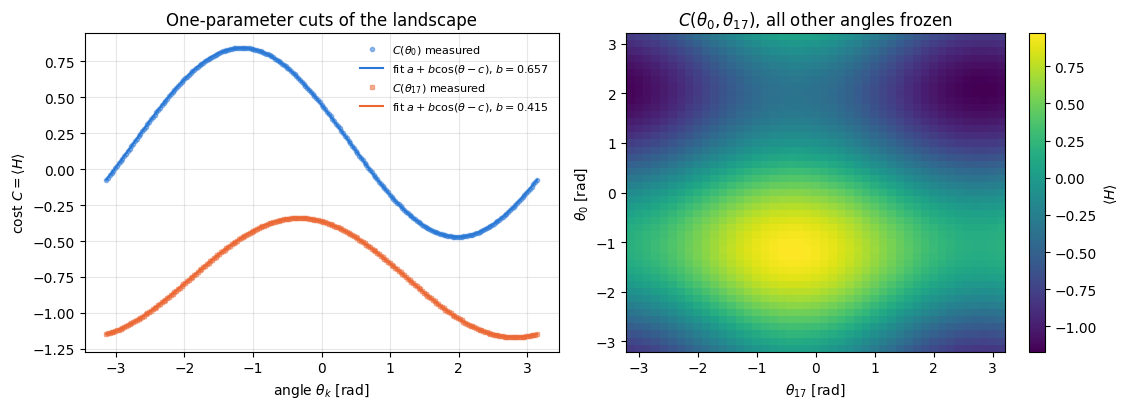


2D landscape: min = -1.169910, max = 0.971630 over the two-angle plane


wrong control, shared angle gamma_1 of the HVA (3 bond gates): max residual 2.91e+00


In [7]:
# ==============================================================================
# STEP 4: scan one angle, fit a + b cos(theta - c), measure the residual
# ==============================================================================
N_LS, L_LS = 5, 3                                    # a not-too-small circuit: 5 qubits, 3 entangling layers
terms_ls = heisenberg_terms(N_LS, Jxx=0.0, Jyy=0.0, Jzz=1.0, hx=0.8)     # TFIM cost
key = jax.random.PRNGKey(7)
theta_ls = jax.random.uniform(key, (hea_num_params(N_LS, L_LS),), minval=-jnp.pi, maxval=jnp.pi)

cost_ls = jax.jit(lambda t: cost_energy(t, terms_ls, N_LS, L_LS))


def scan_one_angle(cost, theta, k, grid):
    """C as a function of theta_k alone, evaluated on `grid`, with every other angle frozen.

    JAX   `vmap` runs all grid points as one batched call: the circuit is compiled once, not len(grid) times.
    """
    e_k = jnp.zeros_like(theta).at[k].set(1.0)
    return jax.vmap(lambda v: cost(theta.at[k].set(v)))(grid), e_k


def fit_sinusoid(grid, values):
    """Least-squares fit of a + b cos(theta - c) written linearly as a + A cos(theta) + B sin(theta).

    MATH   b = sqrt(A^2 + B^2),  c = atan2(B, A)       (because A = b cos c, B = b sin c)
    Returns (a, b, c, max residual).
    """
    M = np.stack([np.ones_like(grid), np.cos(grid), np.sin(grid)], axis=1)
    coef, *_ = np.linalg.lstsq(M, values, rcond=None)
    a, A, B = coef
    resid = float(np.max(np.abs(M @ coef - values)))
    return float(a), float(np.hypot(A, B)), float(np.arctan2(B, A)), resid


grid = np.linspace(-np.pi, np.pi, 241)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
print("one-angle cuts of C(theta) = <H>, fitted with a + b cos(theta - c):")
print(f"{'angle k':>8s} {'a':>12s} {'b':>12s} {'c':>12s} {'max residual':>14s}")
for i, k in enumerate((0, 17)):
    vals, _ = scan_one_angle(cost_ls, theta_ls, k, jnp.asarray(grid))
    vals = np.asarray(vals)
    a, b, c, resid = fit_sinusoid(grid, vals)
    print(f"{k:8d} {a:12.6f} {b:12.6f} {c:12.6f} {resid:14.2e}")
    assert resid < TOL
    axes[0].plot(grid, vals, MARKERS[i], ms=3, color=PALETTE[i], alpha=0.5,
                 label=f"$C(\\theta_{{{k}}})$ measured")
    axes[0].plot(grid, a + b * np.cos(grid - c), "-", color=PALETTE[i], lw=1.5,
                 label=f"fit $a+b\\cos(\\theta-c)$, $b={b:.3f}$")
axes[0].set_xlabel(r"angle $\theta_k$ [rad]"); axes[0].set_ylabel(r"cost $C=\langle H\rangle$")
axes[0].set_title("One-parameter cuts of the landscape"); axes[0].legend(fontsize=8)

# --- two-angle landscape: a 2D heat map ---------------------------------------------------
g2 = np.linspace(-np.pi, np.pi, 45)
G1, G2 = np.meshgrid(g2, g2, indexing="ij")


def two_angle(v1, v2):
    return cost_ls(theta_ls.at[0].set(v1).at[17].set(v2))


Zmap = np.asarray(jax.vmap(jax.vmap(two_angle, in_axes=(None, 0)), in_axes=(0, None))(jnp.asarray(g2), jnp.asarray(g2)))
im = axes[1].pcolormesh(G2, G1, Zmap, cmap="viridis", shading="auto")
axes[1].set_xlabel(r"$\theta_{17}$ [rad]"); axes[1].set_ylabel(r"$\theta_{0}$ [rad]")
axes[1].set_title(r"$C(\theta_0,\theta_{17})$, all other angles frozen")
axes[1].grid(False)
fig.colorbar(im, ax=axes[1], label=r"$\langle H\rangle$")
fig.tight_layout(); plt.show()

print(f"\n2D landscape: min = {Zmap.min():.6f}, max = {Zmap.max():.6f} over the two-angle plane")

# --- wrong control: an angle SHARED by several gates (gamma_1 of the HVA, N = 4, L = 2) ----------
terms_hva = heisenberg_terms(4, Jxx=0.0, Jyy=0.0, Jzz=1.0, hx=0.8)
theta_hva = jax.random.uniform(jax.random.PRNGKey(8), (hva_num_params(2),), minval=-jnp.pi, maxval=jnp.pi)
cut_hva = np.asarray(jax.vmap(lambda v: energy(terms_hva, hva_tfim(theta_hva.at[0].set(v), 4, 2, J=1.0, h=0.8)))(
    jnp.asarray(grid)))
resid_hva = fit_sinusoid(grid, cut_hva)[3]
print(f"wrong control, shared angle gamma_1 of the HVA (3 bond gates): max residual {resid_hva:.2e}")
assert resid_hva > 1e-2

The residual of the three-parameter fit is at the level of $10^{-15}$, i.e. round-off: the cut is exactly the sinusoid
of Eq. (13). The wrong control behaves as it must: for the shared angle $\gamma_1$ of the Hamiltonian-variational
ansatz the same fit leaves a residual of $2.9$, because that cut has the frequencies $2,4,6$ (the gaps of $\sum_{q=0}^{2}Z_qZ_{q+1}$ at $J=1$) and none at frequency
$1$.
The two-angle map shows the consequence of Eq. (13) in two variables: the cost is a sum of products of
$\{1,\cos\theta,\sin\theta\}$ in each angle, with no structure finer than one period. On the torus
$[-\pi,\pi)^2$ this particular cut has a single minimum and a single maximum; the two dark regions at the top of the map
are the same minimum, cut in two by the periodic boundary at $\theta_{17}=\pm\pi$. Local minima of the full
$n$-dimensional landscape are the subject of Section 14 of the next notebook.

> **Numerical practice.** Fitting a model that theory says is exact is a cheap and strong test of an implementation.
> A residual of $10^{-15}$ says the gate conventions, the einsum axes and the cost function are mutually consistent;
> a residual of $10^{-3}$ would have exposed a bug that no eyeballed plot would show.

## 7. Gradient method 1: finite differences

The simplest method uses only cost evaluations. From the Taylor expansion of $C$ around $\theta_k$,

$$C(\theta_k\pm h)=C\pm hC'+\tfrac{h^2}{2}C''\pm\tfrac{h^3}{6}C'''+O(h^4),$$

the odd-order terms survive in the difference and the even ones cancel:

$$\frac{C(\theta_k+h)-C(\theta_k-h)}{2h}=C'(\theta_k)+\frac{h^2}{6}C'''(\theta_k)+O(h^4). \tag{15}$$

### 7.1 The two error sources and the optimal step

Equation (15) has **truncation error** $\varepsilon_{\text{trunc}}\simeq\tfrac{h^2}{6}\lvert C'''\rvert$, which shrinks
as $h\to0$. But $C$ is evaluated in floating point with a relative error of order the machine epsilon
$\varepsilon_{\text{m}}\approx2.2\cdot10^{-16}$ in double precision, and that absolute error
$\varepsilon_{\text{m}}\lvert C\rvert$ is divided by $2h$:

$$\varepsilon_{\text{round}}\simeq\frac{\varepsilon_{\text{m}}\lvert C\rvert}{h}.$$

The total error $E(h)=\tfrac{h^2}{6}\lvert C'''\rvert+\varepsilon_{\text{m}}\lvert C\rvert/h$ is minimised where
$dE/dh=0$:

$$\frac{h}{3}\lvert C'''\rvert=\frac{\varepsilon_{\text{m}}\lvert C\rvert}{h^{2}}
  \quad\Longrightarrow\quad
  h_\star=\Bigl(\frac{3\,\varepsilon_{\text{m}}\lvert C\rvert}{\lvert C'''\rvert}\Bigr)^{1/3}. \tag{16}$$

At the optimum the round-off term equals half the truncation term, $\varepsilon_{\text m}\lvert C\rvert/h_\star=
\tfrac{h_\star^2}{3}\lvert C'''\rvert$, so the smallest achievable error is

$$E(h_\star)=\frac{h_\star^2}{2}\lvert C'''\rvert=\frac12\bigl(3\varepsilon_{\text m}\lvert C\rvert\bigr)^{2/3}
  \lvert C'''\rvert^{1/3}.$$

For a cost and derivatives of order unity, $h_\star\approx(3\cdot2.2\cdot10^{-16})^{1/3}\approx9\cdot10^{-6}$ and
$E(h_\star)\approx\tfrac12\,3^{2/3}\varepsilon_{\text m}^{2/3}\approx1.04\,\varepsilon_{\text m}^{2/3}\approx4\cdot10^{-11}$.
**About a third of the significant digits (five of sixteen) are lost, whatever $h$ we choose.** In single precision,
$\varepsilon_{\text m}\approx1.2\cdot10^{-7}$, the same formulas give $h_\star\approx7\cdot10^{-3}$ and
$E(h_\star)\approx2.5\cdot10^{-5}$, i.e. only four or five correct digits. This loss is the basic objection to finite
differences, and it exists before any shot noise.

Along a single angle the third derivative does not have to be guessed. By Eq. (13), $C=a+b\cos(\theta-c)$, so
$C'''=b\sin(\theta-c)=-C'$ exactly, and Eq. (16) becomes $h_\star=(3\varepsilon_{\text m}\lvert C\rvert/\lvert
C'\rvert)^{1/3}$. The truncation error itself is known in closed form: the central difference of a sinusoid is
$C'\,\sin h/h$, so $\varepsilon_{\text{trunc}}=\lvert C'\rvert(1-\sin h/h)\simeq\tfrac{h^2}{6}\lvert C'\rvert$.

We measure both branches. The reference gradient is `jax.grad`, which Section 10 shows is exact to machine precision.

exact derivative dC/dtheta_3 (jax.grad) = 0.469697925601535


cost at the expansion point             C = -0.459761759529001



machine epsilon of the working dtype            = 2.22e-16
predicted optimal step  h* (Eq. 16, |C'''|=|C'|) = 8.67e-06
measured  optimal step  h* (grid of 1/3 decade)  = 1.00e-05
predicted smallest error E(h*)                   = 1.77e-11
measured  error at the grid point h*             = 6.28e-12   at its two neighbours 3.52e-11, 3.99e-11
measured  error at h = 1e-12                     = 7.36e-05


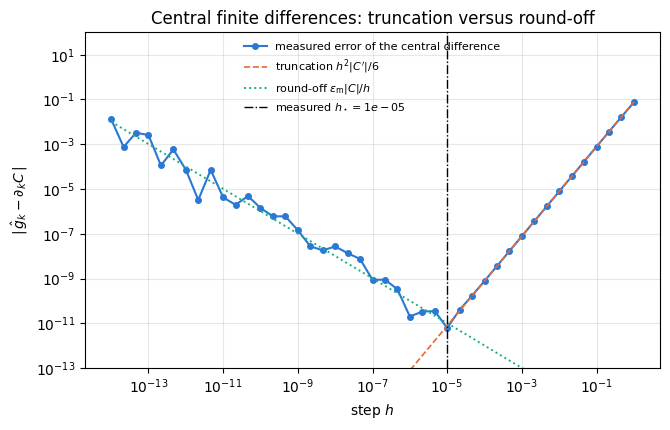

In [8]:
# ==============================================================================
# STEP 5: finite-difference error versus step size -- the V-shaped curve
# ==============================================================================
K_FD = 3                                    # the component we differentiate
g_exact = float(jax.grad(cost_ls)(theta_ls)[K_FD])
print(f"exact derivative dC/dtheta_{K_FD} (jax.grad) = {g_exact:.15f}")
print(f"cost at the expansion point             C = {float(cost_ls(theta_ls)):.15f}")

e_k = jnp.zeros_like(theta_ls).at[K_FD].set(1.0)
hs = np.logspace(-14, 0, 43)
fd = np.asarray(jax.vmap(lambda h: (cost_ls(theta_ls + h * e_k) - cost_ls(theta_ls - h * e_k)) / (2 * h))(jnp.asarray(hs)))
err_fd = np.abs(fd - g_exact)

i_best = int(np.argmin(err_fd))
eps_m = float(np.finfo(np.asarray(theta_ls).dtype).eps)
C_0 = abs(float(cost_ls(theta_ls)))
h_pred = (3 * eps_m * C_0 / abs(g_exact)) ** (1 / 3)              # Eq. (16) with |C'''| = |C'| (Eq. 13)
E_pred = 0.5 * (3 * eps_m * C_0) ** (2 / 3) * abs(g_exact) ** (1 / 3)
print(f"\nmachine epsilon of the working dtype            = {eps_m:.2e}")
print(f"predicted optimal step  h* (Eq. 16, |C'''|=|C'|) = {h_pred:.2e}")
print(f"measured  optimal step  h* (grid of 1/3 decade)  = {hs[i_best]:.2e}")
print(f"predicted smallest error E(h*)                   = {E_pred:.2e}")
print(f"measured  error at the grid point h*             = {err_fd[i_best]:.2e}   at its two neighbours "
      f"{err_fd[i_best - 1]:.2e}, {err_fd[i_best + 1]:.2e}")
print(f"measured  error at h = 1e-12                     = {err_fd[np.argmin(np.abs(hs - 1e-12))]:.2e}")

fig, ax = plt.subplots(figsize=(6.8, 4.4))
ax.loglog(hs, err_fd, "o-", ms=4, color=PALETTE[0], label="measured error of the central difference")
ax.loglog(hs, hs ** 2 / 6 * abs(g_exact), "--", color=PALETTE[1], lw=1.2,
          label=r"truncation $h^2\vert C'\vert/6$")
ax.loglog(hs, eps_m * C_0 / hs, ":", color=PALETTE[2], lw=1.4,
          label=r"round-off $\varepsilon_{\rm m}\vert C\vert/h$")
ax.axvline(hs[i_best], color="k", lw=1, ls="-.", label=f"measured $h_\\star={hs[i_best]:.0e}$")
ax.set_xlabel(r"step $h$"); ax.set_ylabel(r"$\vert\,\hat g_k - \partial_k C\,\vert$")
ax.set_ylim(1e-13, 1e2)
ax.set_title("Central finite differences: truncation versus round-off")
ax.legend(fontsize=8, loc="upper center")
fig.tight_layout(); plt.show()

The measured curve is the textbook V. On the right the error lies on the truncation line $h^2\lvert C'\rvert/6$ from
$h\approx2\cdot10^{-5}$ up to $h=1$, almost five decades; on the left it scatters around the round-off line
$\varepsilon_{\text m}\lvert C\rvert/h$, which is an order-of-magnitude model of the error of a difference of two
floating-point numbers, not a bound. The minimum of the measured grid is at $h=10^{-5}$, the grid point nearest to the
predicted $h_\star=8.7\cdot10^{-6}$. The error there, $6.3\cdot10^{-12}$, is three times below the predicted
$E(h_\star)=1.8\cdot10^{-11}$ and even below the truncation error alone ($7.8\cdot10^{-12}$ at $h=10^{-5}$): at this
grid point the round-off happens to have the opposite sign and cancels part of the truncation. The two neighbouring grid
points, with $3.5\cdot10^{-11}$ and $4.0\cdot10^{-11}$, are closer to the typical value. The relative error at the
optimum is $1.3\cdot10^{-11}$, so about five of the sixteen decimal digits are lost, and no choice of $h$ recovers them.

> **Common pitfall.** The intuition "smaller step, better derivative" is wrong for every finite-difference scheme in
> floating point. A step of $10^{-12}$ gives an error of $7\cdot10^{-5}$ here, seven orders of magnitude worse than the
> optimum.

## 8. Gradient method 2: the parameter-shift rule

### 8.1 Derivation for Pauli rotations

Section 6 proved that $C(\theta)=a+b\cos(\theta-c)$ exactly when $\theta$ enters one gate $e^{-i\theta P/2}$ with
$P^2=\mathbb 1$. Differentiate:

$$C'(\theta)=-b\sin(\theta-c).$$

Now evaluate the same function at two shifted points and subtract. With $s$ an arbitrary shift,

$$\begin{aligned}
C(\theta+s)-C(\theta-s)&=b\bigl[\cos(\theta-c+s)-\cos(\theta-c-s)\bigr]\\
&=b\bigl[-2\sin(\theta-c)\sin s\bigr]=2\sin(s)\,C'(\theta),
\end{aligned}$$

using $\cos(u+s)-\cos(u-s)=-2\sin u\sin s$. Therefore, for **any** $s$ that is not a multiple of $\pi$,

$$\boxed{\;\partial_kC(\boldsymbol\theta)=\frac{C(\boldsymbol\theta+s\,\mathbf e_k)-C(\boldsymbol\theta-s\,\mathbf e_k)}
  {2\sin s}\;}\tag{17}$$

This arbitrary-shift form is given by Mari, Bromley and Killoran (2021). The canonical choice $s=\pi/2$ makes the
denominator $2$:

$$\partial_kC=\tfrac12\bigl[C(\boldsymbol\theta+\tfrac\pi2\mathbf e_k)-C(\boldsymbol\theta-\tfrac\pi2\mathbf e_k)\bigr].
  \tag{18}$$

Three properties follow.

1. **Equation (18) is exact.** It has no truncation error, because the function it differentiates is exactly a
   sinusoid; the large step $\pi/2$ costs nothing in accuracy.
2. **The shifted circuits are ordinary circuits.** They need no access to amplitudes and no extra hardware: the same
   device is run with one angle changed by $\pi/2$. For this reason the rule is used on hardware (Mitarai *et al.*,
   2018). Schuld *et al.* (2019) extended it to every gate $e^{-i\theta G}$ whose generator has two eigenvalues
   $\pm r$, with shift $\pi/(4r)$ and prefactor $r$, and treated other gates with one ancilla qubit.
3. **The cost is $2n$ circuit evaluations** for $n$ parameters. This is the method's weakness, and Sections 9 and 10
   describe the two alternatives.

Equation (17) also shows *why* $s=\pi/2$: small $s$ is allowed mathematically but divides two nearly equal numbers by a
small $\sin s$, which amplifies round-off — the same catastrophe as finite differences. We measure that too.

n_params = 40
max |grad_parameter_shift - grad_autodiff| = 7.77e-16



shift s = pi/2 : error 4.44e-16
shift s = 1e-4 : error 4.89e-12
shift s = 1e-8 : error 2.72e-08


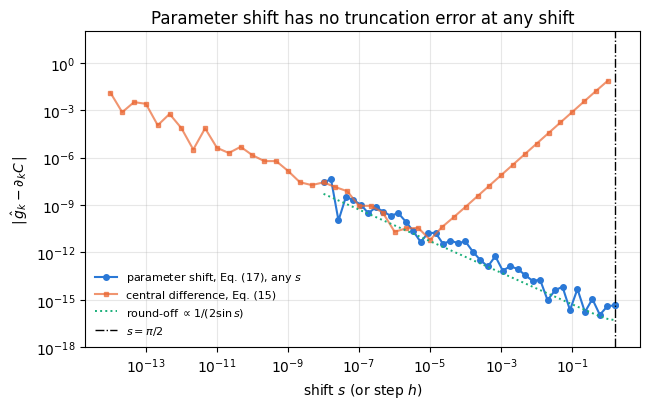

In [9]:
# ==============================================================================
# STEP 6: the parameter-shift rule is EXACT, and the shift s = pi/2 is optimally conditioned
# ==============================================================================
g_ad = jax.grad(cost_ls)(theta_ls)                                    # reference: reverse-mode AD (Section 10)
g_ps = parameter_shift_grad(cost_ls, theta_ls)                        # engine: vmapped two-term rule, s = pi/2
print(f"n_params = {theta_ls.size}")
print(f"max |grad_parameter_shift - grad_autodiff| = {max_abs(g_ps - g_ad):.2e}")
assert max_abs(g_ps - g_ad) < TOL

shifts = np.concatenate([np.logspace(-8, np.log10(np.pi / 2), 40), [np.pi / 2]])
err_s = np.asarray(jax.vmap(lambda s: jnp.abs(
    (cost_ls(theta_ls + s * e_k) - cost_ls(theta_ls - s * e_k)) / (2 * jnp.sin(s)) - g_exact))(jnp.asarray(shifts)))
print(f"\nshift s = pi/2 : error {err_s[-1]:.2e}")
print(f"shift s = 1e-4 : error {err_s[np.argmin(np.abs(shifts - 1e-4))]:.2e}")
print(f"shift s = 1e-8 : error {err_s[0]:.2e}")

fig, ax = plt.subplots(figsize=(6.6, 4.2))
ax.loglog(shifts, np.maximum(err_s, 1e-18), "o-", ms=4, color=PALETTE[0],
          label=r"parameter shift, Eq. (17), any $s$")
ax.loglog(hs, err_fd, "s-", ms=3, color=PALETTE[1], alpha=0.7, label="central difference, Eq. (15)")
ax.loglog(shifts, eps_m * C_0 / (2 * np.sin(shifts)), ":", color=PALETTE[2], lw=1.4,
          label=r"round-off $\propto 1/(2\sin s)$")
ax.axvline(np.pi / 2, color="k", lw=1, ls="-.", label=r"$s=\pi/2$")
ax.set_xlabel(r"shift $s$ (or step $h$)"); ax.set_ylabel(r"$\vert\,\hat g_k-\partial_kC\,\vert$")
ax.set_ylim(1e-18, 1e2)
ax.set_title("Parameter shift has no truncation error at any shift")
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout(); plt.show()

The parameter-shift gradient agrees with automatic differentiation to below $10^{-15}$: there is no truncation error
to measure. The only error is round-off, and it follows the $1/(2\sin s)$ line all the way down; at $s=\pi/2$ the
denominator is as large as it can be, so this is the best-conditioned member of the family. The finite-difference curve
from Section 7 is drawn on the same axes for scale. Its best point, $6\cdot10^{-12}$, lies about four orders of
magnitude above the parameter-shift error at $s=\pi/2$, and the parameter-shift curve stays below it for every shift
$s\gtrsim10^{-5}$. For small $s$ the two curves merge, because Eq. (17) then reduces to the central difference.

### 8.2 Generators with more than two eigenvalues: the four-term rule

For a controlled rotation the cost along that angle is Eq. (14), a trigonometric polynomial with the two frequencies
$\tfrac12$ and $1$. The two-term rule then gives a wrong gradient. Four evaluations are enough, and the coefficients
follow from a two-by-two linear system. Write Eq. (14) around the current angle $\theta$, i.e. as a function of the
shift $u$: $C(\theta+u)=A_0+A_{1/2}\cos\tfrac u2+B_{1/2}\sin\tfrac u2+A_1\cos u+B_1\sin u$, with coefficients that
depend on $\theta$ (a shift of the argument only mixes $\cos$ and $\sin$ of the same frequency). Define the antisymmetric
part $\Delta(s)\equiv C(\theta+s)-C(\theta-s)$. Only the sine terms survive it:

$$\Delta(s)=2\,B_{1/2}\sin\tfrac{s}{2}+2\,B_{1}\sin s .$$

Evaluate at $s=\pi/2$ and $s=3\pi/2$, using $\sin\tfrac\pi4=\sin\tfrac{3\pi}{4}=\tfrac{1}{\sqrt2}$,
$\sin\tfrac\pi2=1$, $\sin\tfrac{3\pi}{2}=-1$:

$$\Delta_1\equiv\Delta(\tfrac\pi2)=\sqrt2\,B_{1/2}+2B_1,\qquad
  \Delta_2\equiv\Delta(\tfrac{3\pi}{2})=\sqrt2\,B_{1/2}-2B_1 .$$

Solving, $B_{1/2}=(\Delta_1+\Delta_2)/(2\sqrt2)$ and $B_1=(\Delta_1-\Delta_2)/4$. The derivative at $\theta$ is the
derivative at $u=0$, where only the sine terms contribute: $C'=\tfrac12 B_{1/2}+B_1$, so

$$\boxed{\;\partial_kC=\frac{\sqrt2+1}{4\sqrt2}\,\Delta_1-\frac{\sqrt2-1}{4\sqrt2}\,\Delta_2\;}\tag{19}$$

with $\Delta_1=C(\theta+\tfrac\pi2)-C(\theta-\tfrac\pi2)$ and $\Delta_2=C(\theta+\tfrac{3\pi}{2})-C(\theta-\tfrac{3\pi}{2})$.
This is the **four-term shift rule** of Anselmetti *et al.* (2021). Wierichs *et al.* (2022) derive it again as a
special case of a general rule: for a cost with $R$ equidistant frequencies, $2R$ evaluations at evenly spaced shifts give
the exact derivative (they also treat arbitrary spectra). We verify Eq. (19), and the failure of the two-term rule,
numerically.

one-angle cut of a controlled-rotation circuit, fitted with
   3 functions  (1, cos t, sin t)                       -> max residual 1.85e-01
   5 functions  (1, cos t, sin t, cos t/2, sin t/2)     -> max residual 5.41e-16



controlled-rotation circuit, n_params = 6
  two-term rule  vs autodiff: max error 2.11e-01   <-- WRONG
  four-term rule vs autodiff: max error 3.61e-16   <-- exact


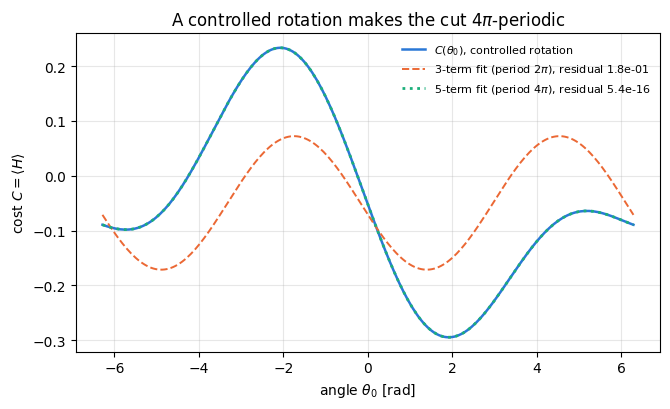

In [10]:
# ==============================================================================
# STEP 7: a circuit with controlled rotations -- the two-term rule fails, the four-term rule works
# ==============================================================================
def crot_ansatz(theta, N, layers):
    """A circuit whose parametrized gates are CONTROLLED rotations CRy, generator |1><1| (x) Y/2.

    Structure per layer: Ry(fixed) on all qubits to leave the computational basis, then a ladder of CRy(theta)
    on neighbouring pairs. The generator eigenvalues are {0, 0, +1/2, -1/2}: three distinct values, two gaps.
    """
    theta = theta.reshape(layers, N - 1)
    psi = zero_state(N)
    for l in range(layers):
        for q in range(N):
            psi = apply_gate(psi, ry(0.9 + 0.3 * q), [q])
        for q in range(N - 1):
            psi = apply_gate(psi, controlled(ry(theta[l, q])), [q, q + 1])
    return psi


N_CR, L_CR = 4, 2
n_cr = L_CR * (N_CR - 1)
terms_cr = heisenberg_terms(N_CR, Jxx=0.0, Jyy=0.0, Jzz=1.0, hx=0.5)
cost_cr = jax.jit(lambda t: energy(terms_cr, crot_ansatz(t, N_CR, L_CR)))
theta_cr = jax.random.uniform(jax.random.PRNGKey(11), (n_cr,), minval=-jnp.pi, maxval=jnp.pi)

# the one-angle cut now needs FIVE basis functions, not three
grid_cr = np.linspace(-2 * np.pi, 2 * np.pi, 241)
vals_cr = np.asarray(jax.vmap(lambda v: cost_cr(theta_cr.at[0].set(v)))(jnp.asarray(grid_cr)))
M3 = np.stack([np.ones_like(grid_cr), np.cos(grid_cr), np.sin(grid_cr)], axis=1)
M5 = np.concatenate([M3, np.stack([np.cos(grid_cr / 2), np.sin(grid_cr / 2)], axis=1)], axis=1)
r3 = float(np.max(np.abs(M3 @ np.linalg.lstsq(M3, vals_cr, rcond=None)[0] - vals_cr)))
r5 = float(np.max(np.abs(M5 @ np.linalg.lstsq(M5, vals_cr, rcond=None)[0] - vals_cr)))
print(f"one-angle cut of a controlled-rotation circuit, fitted with")
print(f"   3 functions  (1, cos t, sin t)                       -> max residual {r3:.2e}")
print(f"   5 functions  (1, cos t, sin t, cos t/2, sin t/2)     -> max residual {r5:.2e}")
assert r5 < TOL < r3


def four_term_grad(f, theta):
    """Four-term parameter-shift rule, Eq. (19), for generators with frequencies {1/2, 1}.

    MATH   dC/dtheta_k = d1*[C(+pi/2)-C(-pi/2)] - d2*[C(+3pi/2)-C(-3pi/2)],
           d1 = (sqrt2+1)/(4 sqrt2),  d2 = (sqrt2-1)/(4 sqrt2)
    COST   4 circuit evaluations per parameter (twice the two-term rule).
    JAX    vmap over the unit vectors e_k batches all 4n circuits into one call.
    """
    d1 = (jnp.sqrt(2.0) + 1) / (4 * jnp.sqrt(2.0))
    d2 = (jnp.sqrt(2.0) - 1) / (4 * jnp.sqrt(2.0))
    eye = jnp.eye(theta.size).reshape((theta.size,) + theta.shape)

    def one(e):
        D1 = f(theta + (jnp.pi / 2) * e) - f(theta - (jnp.pi / 2) * e)
        D2 = f(theta + (3 * jnp.pi / 2) * e) - f(theta - (3 * jnp.pi / 2) * e)
        return d1 * D1 - d2 * D2

    return jax.vmap(one)(eye).reshape(theta.shape)


g_cr_ad = jax.grad(cost_cr)(theta_cr)
g_cr_2 = parameter_shift_grad(cost_cr, theta_cr)
g_cr_4 = four_term_grad(cost_cr, theta_cr)
print(f"\ncontrolled-rotation circuit, n_params = {n_cr}")
print(f"  two-term rule  vs autodiff: max error {max_abs(g_cr_2 - g_cr_ad):.2e}   <-- WRONG")
print(f"  four-term rule vs autodiff: max error {max_abs(g_cr_4 - g_cr_ad):.2e}   <-- exact")
assert max_abs(g_cr_4 - g_cr_ad) < TOL and max_abs(g_cr_2 - g_cr_ad) > 1e-3

fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.plot(grid_cr, vals_cr, "-", color=PALETTE[0], lw=1.8, label=r"$C(\theta_0)$, controlled rotation")
ax.plot(grid_cr, M3 @ np.linalg.lstsq(M3, vals_cr, rcond=None)[0], "--", color=PALETTE[1], lw=1.4,
        label=f"3-term fit (period $2\\pi$), residual {r3:.1e}")
ax.plot(grid_cr, M5 @ np.linalg.lstsq(M5, vals_cr, rcond=None)[0], ":", color=PALETTE[2], lw=2.0,
        label=f"5-term fit (period $4\\pi$), residual {r5:.1e}")
ax.set_xlabel(r"angle $\theta_0$ [rad]"); ax.set_ylabel(r"cost $C=\langle H\rangle$")
ax.set_title("A controlled rotation makes the cut $4\\pi$-periodic")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

The measurement confirms the analysis. The one-angle cut of a controlled-rotation circuit is not a $2\pi$-periodic
sinusoid: the three-function fit leaves a residual of $0.18$, while adding the half-frequency pair reduces it to
round-off. Consequently the two-term rule is off by $0.21$ in the worst component, an error of the formula rather than of
the numerics, and the four-term rule of Eq. (19) reproduces automatic differentiation to $4\cdot10^{-16}$.

> **Common pitfall.** "Parameter shift" denotes a family of rules indexed by the generator's spectrum. Applying the
> $\pi/2$ two-term formula to a controlled rotation, a two-qubit gate with a non-Pauli generator, an $R_{ZZ}(2J\gamma)$
> with $J\neq\tfrac12$, or an angle shared by several gates silently returns a wrong gradient; the optimiser then descends a direction that is not the
> gradient, and the failure looks like "the optimiser is bad". Always check the spectrum first.

## 9. Gradient method 3: SPSA

Parameter shift costs $2n$ circuits. **Simultaneous perturbation stochastic approximation** (Spall, 1992) costs $2$,
independently of $n$ — at the price of returning a random vector whose *mean* is the gradient.

### 9.1 The estimator

Draw a random direction $\boldsymbol\Delta$ whose components are independent and take the values $\pm1$ with probability
$\tfrac12$ each (a Rademacher vector), perturb **all** parameters at once, and define

$$\hat g_k=\frac{C(\boldsymbol\theta+c\boldsymbol\Delta)-C(\boldsymbol\theta-c\boldsymbol\Delta)}{2c\,\Delta_k}. \tag{20}$$

Two evaluations produce a full $n$-component vector, because the single scalar difference is *divided by a different
$\Delta_k$ for each component*. The reason this is not nonsense is the choice of distribution: $\Delta_k^2=1$, so
$1/\Delta_k=\Delta_k$, and the components are uncorrelated.

### 9.2 Bias of the estimator

Taylor-expand both evaluations in $c$:

$$C(\boldsymbol\theta\pm c\boldsymbol\Delta)=C\pm c\sum_j\Delta_j\partial_jC
  +\frac{c^2}{2}\sum_{jl}\Delta_j\Delta_l\partial_j\partial_lC
  \pm\frac{c^3}{6}\sum_{jlm}\Delta_j\Delta_l\Delta_m\partial_j\partial_l\partial_mC+O(c^4).$$

The even orders cancel in the difference, so

$$\hat g_k=\frac{1}{\Delta_k}\sum_j\Delta_j\partial_jC
  +\frac{c^2}{6\Delta_k}\sum_{jlm}\Delta_j\Delta_l\Delta_m\partial_j\partial_l\partial_mC+O(c^4)
  =\partial_kC+\sum_{j\ne k}\Delta_j\Delta_k\,\partial_jC+O(c^2), \tag{21}$$

where the last step used $1/\Delta_k=\Delta_k$ and separated the $j=k$ term ($\Delta_k^2=1$). Taking the expectation over
$\boldsymbol\Delta$ and using $\mathbb E[\Delta_j\Delta_k]=\delta_{jk}$ kills the sum:

$$\mathbb E[\hat g_k]=\partial_kC+c^2\beta_k+O(c^4),\qquad
  \beta_k=\frac16\Bigl[\partial_k^3C+3\sum_{j\ne k}\partial_k\partial_j^2C\Bigr]. \tag{22}$$

The coefficient $\beta_k$ comes from the $c^2$ term of Eq. (21): $\mathbb E[\Delta_k\Delta_j\Delta_l\Delta_m]$ is $1$ when
the four indices form pairs and $0$ otherwise, which leaves $j=l=m=k$ (once) and $\{j,l,m\}=\{k,i,i\}$ with $i\ne k$ (three
placements each). The estimator is therefore unbiased up to a $c^2$ correction built from third derivatives. The sum in
$\beta_k$ runs over all other parameters, so the correction grows with the number of parameters that interact with
$\theta_k$: "small $c$" means $c^2\lvert\beta_k\rvert\ll\lvert\partial_kC\rvert$, a condition that becomes stricter as
the circuit grows.

### 9.3 Variance

From Eq. (21), the fluctuation is $\hat g_k-\partial_kC=\sum_{j\ne k}\Delta_j\Delta_k\partial_jC+O(c^2)$. Squaring and
averaging, the cross terms $\mathbb E[\Delta_j\Delta_l\Delta_k^2]=\delta_{jl}$ leave only the diagonal:

$$\mathrm{Var}(\hat g_k)=\sum_{j\ne k}(\partial_jC)^2+O(c^2)
  =\lVert\nabla C\rVert^2-(\partial_kC)^2+O(c^2). \tag{23}$$

Summing over $k$ gives the mean squared error of the whole gradient vector,

$$\mathbb E\bigl\lVert\hat{\mathbf g}-\nabla C\bigr\rVert^2=(n-1)\,\lVert\nabla C\rVert^2 . \tag{24}$$

So a single SPSA sample has a *relative* error of order $\sqrt{n}$. Its advantage is the price: each sample costs $2$
evaluations instead of $2n$, so at equal budget one can average $n$ samples, which divides Eq. (24) by $n$; and the
optimisers of the next notebook average implicitly through momentum. Section 12 makes the comparison at equal shot
budget when the cost itself is noisy.

The cell below tests Eqs. (22)–(24) with $16\,000$ independent samples per value of $c$. Two checkpoints come with wrong
controls. (a) At $c=0.2$ the sample mean must agree with the leading-order prediction $\partial_kC+c^2\beta_k$ (with
$\beta_k$ from third derivatives computed by nested `jax.jacfwd`/`jax.hessian`), while the plain prediction
$\partial_kC$ must be rejected. (b) At $c=0.01$ the variance of the component $k_\star$ with the largest
$\lvert\partial_kC\rvert$ must agree with Eq. (23), while the wrong formula $\lVert\nabla C\rVert^2$ (forgetting that
the $j=k$ term is not noise) must be rejected.

In [11]:
# ==============================================================================
# STEP 8: SPSA -- measure the bias (Eq. 22) and the variance (Eq. 23)
# ==============================================================================
N_SPSA_DRAWS = 16000
keys = jax.random.split(jax.random.PRNGKey(3), N_SPSA_DRAWS)


@jax.jit
def spsa_batch(keys, c):
    """All SPSA samples of the gradient at theta_ls, batched with vmap (one compiled program)."""
    return jax.vmap(lambda k: spsa_grad(k, cost_ls, theta_ls, c=c))(keys)


n_par = int(theta_ls.size)
g_np = np.asarray(g_ad)
grad_norm2 = float(np.sum(g_np ** 2))
k_star = int(np.argmax(np.abs(g_np)))                       # component with the largest |d_k C|
# third derivatives T[a,b,c] = d_a d_b d_c C, then beta_k of Eq. (22)
T3 = np.asarray(jax.jacfwd(jax.hessian(cost_ls))(theta_ls))
beta_c2 = np.array([(T3[k, k, k] + 3 * (np.trace(T3[k]) - T3[k, k, k])) / 6 for k in range(n_par)])
print(f"n_params = {n_par},  ||grad C||^2 = {grad_norm2:.6f},  k* = {k_star} (d_k* C = {g_np[k_star]:.4f}),  "
      f"{N_SPSA_DRAWS} independent SPSA samples per c\n")
print(f"{'c':>6s} {'max|mean-dC|':>13s} {'noise floor':>12s} {'max c^2|beta|':>14s} {'max|mean-dC-c^2 beta|':>22s} "
      f"{'Var(g_k*)':>10s} {'Eq.(23)':>8s} {'MSE':>8s} {'Eq.(24)':>8s}")
spsa_stats = {}
for c in (0.5, 0.2, 0.05, 0.01):
    G = np.asarray(spsa_batch(keys, c))
    mean, var = G.mean(axis=0), G.var(axis=0)
    sem = np.sqrt(var / N_SPSA_DRAWS)                       # standard error of each sample mean
    mse = float(np.mean(np.sum((G - g_np[None, :]) ** 2, axis=1)))
    bias = float(np.max(np.abs(mean - g_np)))
    bias_lo = float(np.max(np.abs(mean - g_np - c ** 2 * beta_c2)))
    # what the LARGEST of n independent sample means would typically be if the bias were exactly zero:
    # each mean has standard error sqrt(Var/R); the maximum of n such draws is about sqrt(2 ln n) of them.
    noise_floor = float(np.sqrt(np.mean(var) / N_SPSA_DRAWS) * np.sqrt(2 * np.log(n_par)))
    # standard error of the sample variance of component k*, from the fourth central moment
    d = G[:, k_star] - mean[k_star]
    se_var = float(np.sqrt((np.mean(d ** 4) - var[k_star] ** 2) / N_SPSA_DRAWS))
    spsa_stats[c] = dict(z_plain=np.max(np.abs(mean - g_np) / sem),
                         z_lo=np.max(np.abs(mean - g_np - c ** 2 * beta_c2) / sem),
                         var=float(var[k_star]), se_var=se_var)
    print(f"{c:6.2f} {bias:13.4f} {noise_floor:12.4f} {np.max(np.abs(c ** 2 * beta_c2)):14.4f} {bias_lo:22.4f} "
          f"{var[k_star]:10.4f} {grad_norm2 - g_np[k_star] ** 2:8.4f} {mse:8.2f} {(n_par - 1) * grad_norm2:8.2f}")

# --- CHECKPOINT (a): bias at c = 0.2 is the leading-order c^2 term of Eq. (22) ----------------
st = spsa_stats[0.2]
print(f"\n(a) c = 0.2: max_k |mean - d_kC - c^2 beta_k| / SEM = {st['z_lo']:.2f}  (must be < 5)")
print(f"    wrong control, no c^2 term:  max_k |mean - d_kC| / SEM = {st['z_plain']:.2f}  (must be > 5)")
assert st["z_lo"] < 5 and st["z_plain"] > 5
print(f"    c = 0.01: max_k |mean - d_kC| / SEM = {spsa_stats[0.01]['z_plain']:.2f}  (must be < 5)")
assert spsa_stats[0.01]["z_plain"] < 5
# --- CHECKPOINT (b): variance at c = 0.01 is Eq. (23) -------------------------------------------
st = spsa_stats[0.01]
z_var = (st["var"] - (grad_norm2 - g_np[k_star] ** 2)) / st["se_var"]
z_var_wrong = (st["var"] - grad_norm2) / st["se_var"]
print(f"(b) c = 0.01: Var(g_k*) = {st['var']:.4f} +- {st['se_var']:.4f};  Eq. (23) off by {z_var:+.2f} SE (must be |.|<4),"
      f"  wrong control ||grad C||^2 off by {z_var_wrong:+.2f} SE (must be |.|>4)")
assert abs(z_var) < 4 and abs(z_var_wrong) > 4

n_params = 40,  ||grad C||^2 = 6.707135,  k* = 16 (d_k* C = 1.0011),  16000 independent SPSA samples per c

     c  max|mean-dC|  noise floor  max c^2|beta|  max|mean-dC-c^2 beta|  Var(g_k*)  Eq.(23)      MSE  Eq.(24)


  0.50        0.7301       0.0277         1.3080                 0.6258     1.4584   5.7049    69.38   261.58


  0.20        0.1731       0.0472         0.2093                 0.0523     4.1272   5.7049   193.24   261.58


  0.05        0.0674       0.0546         0.0131                 0.0684     5.6085   5.7049   258.52   261.58


  0.01        0.0693       0.0551         0.0005                 0.0693     5.7297   5.7049   263.80   261.58

(a) c = 0.2: max_k |mean - d_kC - c^2 beta_k| / SEM = 3.09  (must be < 5)
    wrong control, no c^2 term:  max_k |mean - d_kC| / SEM = 10.59  (must be > 5)
    c = 0.01: max_k |mean - d_kC| / SEM = 3.48  (must be < 5)
(b) c = 0.01: Var(g_k*) = 5.7297 +- 0.0618;  Eq. (23) off by +0.40 SE (must be |.|<4),  wrong control ||grad C||^2 off by -15.82 SE (must be |.|>4)


The table tests Eqs. (22)–(24) at four probe radii.

* **Bias.** At $c=0.01$ and $c=0.05$ the largest deviation of the sample mean from the exact gradient (about $0.07$)
  is at the sampling noise floor printed beside it, and the predicted $c^2$ bias ($5\cdot10^{-4}$ and $0.013$) is
  below that floor. At $c=0.2$ the deviation, $0.17$, is $3.7$ times the floor, and it is explained by the
  leading-order term of Eq. (22): after subtracting $c^2\beta_k$ the largest residual is $0.05$, at the floor
  (checkpoint (a)). At $c=0.5$ the expansion has broken down: the predicted $c^2\lvert\beta_k\rvert$ reaches $1.3$,
  larger than the gradient components themselves, and the residual stays at $0.63$. With $n=40$ parameters, $c=0.5$ is
  far outside the small-$c$ regime even though $c^2=0.25$ looks modest, because $\beta_k$ collects contributions from all
  the other parameters.
* **Variance.** The variance of component $k_\star$ is $1.46$ at $c=0.5$ against the predicted $5.70$ (the
  higher-order terms *reduce* the spread), $4.13$ at $c=0.2$, and it converges onto Eq. (23) for $c\le0.05$; at
  $c=0.01$ it agrees within $0.4$ standard errors, while the wrong formula $\lVert\nabla C\rVert^2$ is off by $16$
  standard errors (checkpoint (b)). The mean squared error of the full vector behaves the same way and lands on
  $(n-1)\lVert\nabla C\rVert^2$, Eq. (24), to within $1.2\,\%$ at the two smallest $c$.

Equations (22) to (24) therefore describe the small-$c$ limit, and here "small" means $c\lesssim0.05$ radians. A
practitioner who picks $c=0.5$ to reduce the influence of shot noise (Section 12) pays for it with a large bias in the
search direction, which is why Spall's schedule shrinks $c_k$ as the optimisation proceeds (next notebook).

> **Physics insight.** SPSA returns a random vector whose mean equals the gradient up to $O(c^2)$ and whose covariance
> is of order $\lVert\nabla C\rVert^2$ per component. An optimiser driven by it performs stochastic approximation, and
> its convergence theory prescribes decreasing gains $a_k$ and probe radii $c_k$.

## 10. Gradient method 4: reverse-mode automatic differentiation

On a simulator we have something no experiment has: the amplitudes. That allows the gradient of all $n$ parameters to be
computed at the cost of a few circuit evaluations, instead of $2n$.

### 10.1 How reverse mode works on a circuit

Write the circuit as a composition of $n_g$ gates (in this subsection $n_g$ counts *all* gates, parametrized or not).
Let $\vert\psi_0\rangle=\vert0\rangle^{\otimes N}$ and

$$\vert\psi_l\rangle=U_l\vert\psi_{l-1}\rangle\quad(l=1,\dots,n_g),\qquad
  C=\langle\psi_{n_g}\vert\hat O\vert\psi_{n_g}\rangle .$$

Suppose gate $l$ carries the parameter $\theta_l$. Differentiating the product,

$$\frac{\partial C}{\partial\theta_l}
=2\,\mathrm{Re}\;\langle\psi_{n_g}\vert\,\hat O\;U_{n_g}\cdots U_{l+1}\;
  \frac{\partial U_l}{\partial\theta_l}\;\vert\psi_{l-1}\rangle . \tag{25}$$

(the two terms of the product rule are complex conjugates of each other because $\hat O$ is Hermitian, hence
$2\,\mathrm{Re}$). The naive reading of Eq. (25) is "for each $l$, re-run the circuit", i.e. $O(n\,n_g)$ gate
applications. Reverse mode reorganises it into **two sweeps**:

* **forward sweep.** Apply $U_1,\dots,U_{n_g}$, storing every intermediate $\vert\psi_l\rangle$. Cost $n_g$ gates,
  memory $n_g\cdot2^N$ complex numbers.
* **backward sweep.** Define the *adjoint state* $\vert\lambda_{n_g}\rangle=\hat O\vert\psi_{n_g}\rangle$ and propagate it
  **backwards through the adjoint gates**, $\vert\lambda_{l-1}\rangle=U_l^\dagger\vert\lambda_l\rangle$. Then, reading
  Eq. (25) right to left, $U_{n_g}\cdots U_{l+1}$ acting to the left on $\langle\psi_{n_g}\vert\hat O$ is exactly
  $\langle\lambda_l\vert$, so

$$\frac{\partial C}{\partial\theta_l}=2\,\mathrm{Re}\;\langle\lambda_l\vert\,
  \frac{\partial U_l}{\partial\theta_l}\,\vert\psi_{l-1}\rangle . \tag{26}$$

One backward sweep therefore produces **all** derivatives: at step $l$ we already hold $\vert\lambda_l\rangle$ and
$\vert\psi_{l-1}\rangle$. For $U_l=e^{-i\theta_lP_l/2}$ the derivative gate is $\partial_{\theta}U=-\tfrac{i}{2}P\,U$, so
$\partial_{\theta_l}U_l\vert\psi_{l-1}\rangle=-\tfrac i2P_l\vert\psi_l\rangle$ costs one Pauli application and one inner
product. In total: $n_g$ gates forward, $n_g$ adjoint gates on $\vert\lambda\rangle$, one Pauli per parameter, and one
application of $\hat O$, i.e. a small constant multiple of one circuit evaluation, whatever $n$ is.

### 10.2 Memory, and the adjoint trick

The forward sweep as described stores $n_g$ states: memory $O(n_g\cdot2^N)$ against the $O(2^N)$ of a parameter-shift
evaluation. For $N=20$ and $n_g=200$ that is $200\times16.8\,\text{MB}\approx3.4\,\text{GB}$, which limits the method.

The **adjoint-differentiation** method, derived for state-vector simulators by Jones and Gacon (2020), removes this
memory. Quantum gates are unitary, so
$\vert\psi_{l-1}\rangle=U_l^\dagger\vert\psi_l\rangle$: the forward states can be *recomputed backwards* instead of
stored. The backward sweep then carries exactly two state vectors, $\vert\psi\rangle$ and $\vert\lambda\rangle$, both
marching from $n_g$ down to $1$, and the memory drops to $O(2^N)$, the same as one circuit evaluation, at the price of
one extra gate application per step (about $3n_g$ gate applications in total). The method has no analogue on hardware,
where $U_l^\dagger$ cannot be applied to a state that has already been measured.

We implement the adjoint method by hand, to make Eq. (26) concrete, and check it against `jax.grad`.

In [12]:
# ==============================================================================
# STEP 9: adjoint differentiation, written out, versus jax.grad
# ==============================================================================
def hea_gate_list(theta, N, layers):
    """The hardware-efficient ansatz written as an explicit ordered list of gates.

    Returns a list of tuples (qubits, U, generator_or_None). `generator` is the Hermitian P with U = exp(-i theta P/2)
    for PARAMETRIZED gates (in the order the angles appear in `theta`), and None for the fixed CZ entanglers.
    """
    th = theta.reshape(layers + 1, N, 2)
    gates = []
    for l in range(layers + 1):
        for q in range(N):
            gates.append(((q,), ry(th[l, q, 0]), Y))
            gates.append(((q,), rz(th[l, q, 1]), Z))
        if l < layers:
            for q in range(N - 1):
                gates.append(((q, q + 1), CZ, None))
    return gates


def adjoint_gradient(theta, N, layers, terms):
    """Gradient of <H> through a circuit by the ADJOINT method, Eq. (26), with O(2^N) memory.

    ALGORITHM
    ---------
      forward :  psi = U_{n_g} ... U_1 |0..0>                (only the FINAL state is kept)
      seed    :  lambda = H psi
      backward:  for l = n_g..1:                             (psi = psi_l, lambda = lambda_l on entry)
                     if gate l is parametrized with generator P:
                         g_l = 2 Re <lambda | (-i P/2) psi >     ((dU_l/dtheta)|psi_{l-1}> = (-i P/2) U_l|psi_{l-1}>)
                     psi    <- U_l^dag psi                   (recompute psi_{l-1} -- no storage needed)
                     lambda <- U_l^dag lambda
    COST   n_g gates forward + 2 n_g adjoint gates + n Pauli applications + one H application,
           and n inner products, for ALL n derivatives.
    MEMORY two state tensors, O(2^N) -- independent of the circuit depth.
    """
    gates = hea_gate_list(theta, N, layers)
    psi = zero_state(N)
    for qubits, U, _ in gates:                                   # forward sweep
        psi = apply_gate(psi, U, qubits)
    lam = apply_hamiltonian(terms, psi)                          # adjoint seed |lambda> = H|psi>
    grads = []
    for qubits, U, P in reversed(gates):                         # backward sweep
        if P is not None:
            dpsi = apply_gate(psi, -0.5j * P, qubits)            # (dU/dtheta)|psi_{l-1}> = (-i P/2)|psi_l>
            grads.append(2.0 * jnp.real(jnp.vdot(lam, dpsi)))
        Udag = U.conj().T
        psi = apply_gate(psi, Udag, qubits)                      # psi <- psi_{l-1}
        lam = apply_gate(lam, Udag, qubits)                      # lambda <- lambda_{l-1}
    return jnp.array(grads[::-1])                                # gates were traversed in reverse order


g_adj = adjoint_gradient(theta_ls, N_LS, L_LS, terms_ls)
print(f"adjoint method   vs jax.grad: max error {max_abs(g_adj - g_ad):.2e}")
print(f"parameter shift  vs jax.grad: max error {max_abs(g_ps - g_ad):.2e}")
assert max_abs(g_adj - g_ad) < TOL

# --- how much scratch memory does XLA actually reserve for each? ---------------------------
n_gates = len(hea_gate_list(theta_ls, N_LS, L_LS))
state_bytes = 2 ** N_LS * np.dtype(CDTYPE).itemsize
print(f"\ncircuit: N={N_LS}, L={L_LS}, {n_gates} gates, one state = {state_bytes} bytes")
print(f"{'compiled program':>34s} {'XLA scratch memory [bytes]':>28s}")
for name, fn in (("cost C(theta)", cost_ls),
                 ("jax.grad(C) (reverse mode)", jax.grad(cost_ls)),
                 ("adjoint gradient (hand-written)", lambda t: adjoint_gradient(t, N_LS, L_LS, terms_ls)),
                 ("parameter shift (vmapped)", lambda t: parameter_shift_grad(cost_ls, t))):
    print(f"{name:>34s} {compiled_bytes(fn, theta_ls):28d}")

adjoint method   vs jax.grad: max error 7.77e-16
parameter shift  vs jax.grad: max error 7.77e-16

circuit: N=5, L=3, 52 gates, one state = 512 bytes
                  compiled program   XLA scratch memory [bytes]


                     cost C(theta)                         5632


        jax.grad(C) (reverse mode)                        33872


   adjoint gradient (hand-written)                         9664


         parameter shift (vmapped)                       430080


The hand-written adjoint gradient reproduces `jax.grad` to below $10^{-15}$: the chain rule of Eq. (26) is what
reverse-mode automatic differentiation does, written out.

Take the scratch memory of the forward pass as the unit. Reverse-mode `jax.grad` reserves six times as much: XLA keeps the
intermediates it needs for the backward pass, which is the $O(n_g\cdot2^N)$ of Section 10.2 (52 gates of 512 bytes are
26.6 kB, against the measured 33.9 kB), reduced by the buffer reuse XLA can prove safe. The hand-written adjoint version
reserves $1.7$ times the forward pass: two state tensors plus working space, the $O(2^N)$ the algorithm was designed
for. The vmapped parameter shift is the largest, at $76$ times the forward pass: batching all $2n=80$ shifted
circuits into one program means holding eighty copies of the forward pass's working space at once. That is the price of
the speed measured in the next section: `vmap` trades memory for throughput, and the trade is invisible in a wall-time
table. On a larger circuit it decides whether the program fits into memory at all; the remedy is to `vmap` over chunks
of parameters rather than over all of them.

> **JAX practice.** `jax.grad` differentiates *any* pure function of a JAX array, including a whole einsum circuit
> simulator with Python loops over gates: at trace time the loops are unrolled into a graph, and XLA differentiates the
> graph. No part of the engine was written specifically for autodiff; pure functions of arrays are sufficient.

## 11. All four methods: accuracy and cost versus the number of parameters

The circuit is a hardware-efficient ansatz on $N=6$ qubits with the number of layers increasing, so the parameter count
runs from $2\cdot6\cdot2=24$ to $2\cdot6\cdot5=60$. Every method is jitted, compile time is separated from run time (the
first call of every compiled function is excluded and the best of ten later calls is reported, five for the Python loop), and the reported error
is against `jax.grad`. The evaluation counts are *counted from the algorithms*: $2n$ for finite
differences and the two-term parameter shift, $2$ for SPSA, and (for reverse mode) one forward plus one backward sweep.
The time of one forward pass (one cost evaluation) is measured as well, because every claim about "cost in circuit
evaluations" is a claim about the ratio to that time. Since the depth of this ansatz grows with $L$, and $n$ grows with
$L$ too, a forward pass gets more expensive along the table. A second measurement at $N=12$, where one state has
$4096$ amplitudes, shows the ratios once the arithmetic dominates over the fixed cost of launching a compiled call.

> **Numerical practice.** Wall times on a shared machine fluctuate by tens of percent from run to run. Read the table
> for orders of magnitude and for trends, not for its last digit; the *evaluation counts* in the same table are exact
> because they are counted, not timed.

N = 6 qubits, hardware-efficient ansatz, cost = <H_TFIM>
  L    n | fwd [ms] | evals  FD [ms]   FD err | PS loop [ms] PS vmap [ms]   PS err | SPSA [ms] |  AD [ms] AD/fwd


  1   24 |    0.053 |    48     2.20  5.0e-11 |        12.59         0.77  9.4e-16 |     0.121 |    0.162    3.0


  2   36 |    0.174 |    72     2.01  5.1e-11 |        21.69         1.60  5.6e-16 |     0.152 |    0.265    1.5


  3   48 |    0.119 |    96     2.66  8.6e-11 |        31.21         2.33  1.1e-15 |     0.160 |    0.220    1.8


  4   60 |    0.101 |   120     3.50  7.1e-11 |        36.20         3.59  9.0e-16 |     0.180 |    0.287    2.8



N = 12, L = 2, n = 72:  forward 1.61 ms (compile 0.85 s) | jax.grad 5.33 ms = 3.3 x forward (compile 3.44 s) | parameter shift (vmap) 237.0 ms = 147 x forward for 2n = 144 circuits (compile 1.49 s)


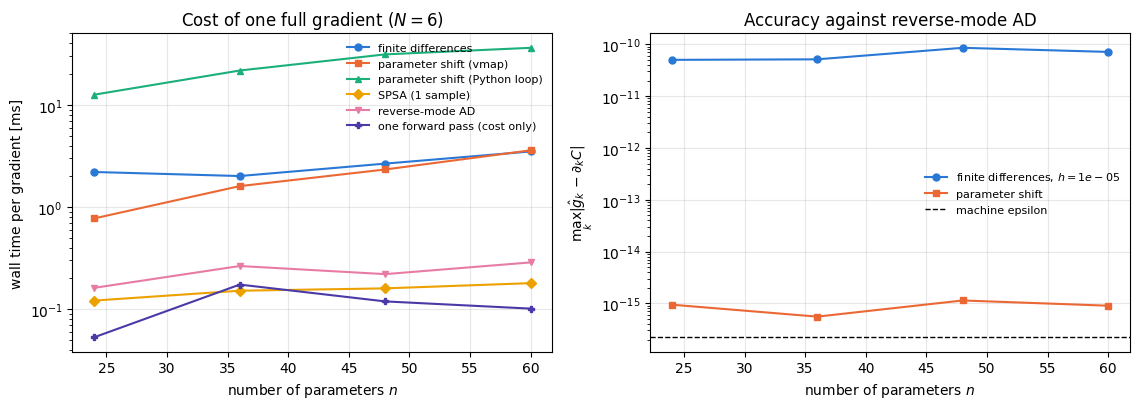

In [13]:
# ==============================================================================
# STEP 10: benchmark the four gradient methods against the parameter count
# ==============================================================================
N_BM = 6
terms_bm = heisenberg_terms(N_BM, Jxx=0.0, Jyy=0.0, Jzz=1.0, hx=0.8)
H_FD = 1e-5                                      # the step measured to be near-optimal in Section 7

print(f"N = {N_BM} qubits, hardware-efficient ansatz, cost = <H_TFIM>")
print(f"{'L':>3s} {'n':>4s} | {'fwd [ms]':>8s} | {'evals':>5s} {'FD [ms]':>8s} {'FD err':>8s} | {'PS loop [ms]':>12s} "
      f"{'PS vmap [ms]':>12s} {'PS err':>8s} | {'SPSA [ms]':>9s} | {'AD [ms]':>8s} {'AD/fwd':>6s}")
bench = []
for L in (1, 2, 3, 4):
    n = hea_num_params(N_BM, L)
    th = jax.random.uniform(jax.random.PRNGKey(100 + L), (n,), minval=-jnp.pi, maxval=jnp.pi)
    cost = jax.jit(lambda t, L=L: cost_energy(t, terms_bm, N_BM, L))
    eye = jnp.eye(n)

    fd_fn = jax.jit(lambda t, eye=eye, cost=cost: jax.vmap(
        lambda e: (cost(t + H_FD * e) - cost(t - H_FD * e)) / (2 * H_FD))(eye))
    ps_vmap_fn = jax.jit(lambda t, cost=cost: parameter_shift_grad(cost, t))
    ad_fn = jax.jit(jax.grad(cost))
    spsa_fn = jax.jit(lambda t, cost=cost: spsa_grad(jax.random.PRNGKey(0), cost, t, c=0.1))

    def ps_loop(t, cost=cost, n=n):
        """The same parameter-shift gradient WITHOUT vmap: 2n separate compiled calls."""
        out = []
        for k in range(n):
            e = jnp.zeros(n).at[k].set(1.0)
            out.append((cost(t + (jnp.pi / 2) * e) - cost(t - (jnp.pi / 2) * e)) / 2)
        return jnp.stack(out)

    _, _, t_fwd = timed(cost, th, repeat=10)          # best of 10: the minimum is the least load-sensitive statistic
    g_ref, _, t_ad = timed(ad_fn, th, repeat=10)
    g_fd, _, t_fd = timed(fd_fn, th, repeat=10)
    g_ps, _, t_ps = timed(ps_vmap_fn, th, repeat=10)
    _, _, t_psl = timed(ps_loop, th, repeat=5)
    _, _, t_spsa = timed(spsa_fn, th, repeat=10)
    e_fd, e_ps = max_abs(g_fd - g_ref), max_abs(g_ps - g_ref)
    bench.append((n, t_fd, t_ps, t_psl, t_spsa, t_ad, e_fd, e_ps, t_fwd))
    print(f"{L:3d} {n:4d} | {t_fwd * 1e3:8.3f} | {2 * n:5d} {t_fd * 1e3:8.2f} {e_fd:8.1e} | {t_psl * 1e3:12.2f} "
          f"{t_ps * 1e3:12.2f} {e_ps:8.1e} | {t_spsa * 1e3:9.3f} | {t_ad * 1e3:8.3f} {t_ad / t_fwd:6.1f}")

# --- the same ratios on a larger register, where the arithmetic dominates the launch overhead -------
N_BIG, L_BIG = 12, 2
n_big = hea_num_params(N_BIG, L_BIG)
terms_big = heisenberg_terms(N_BIG, Jxx=0.0, Jyy=0.0, Jzz=1.0, hx=0.8)
th_big = jax.random.uniform(jax.random.PRNGKey(200), (n_big,), minval=-jnp.pi, maxval=jnp.pi)
cost_big = jax.jit(lambda t: cost_energy(t, terms_big, N_BIG, L_BIG))
_, c_fwd_big, t_fwd_big = timed(cost_big, th_big)
_, c_ad_big, t_ad_big = timed(jax.jit(jax.grad(cost_big)), th_big)
_, c_ps_big, t_ps_big = timed(jax.jit(lambda t: parameter_shift_grad(cost_big, t)), th_big)
print(f"\nN = {N_BIG}, L = {L_BIG}, n = {n_big}:  forward {t_fwd_big * 1e3:.2f} ms (compile {c_fwd_big:.2f} s) | "
      f"jax.grad {t_ad_big * 1e3:.2f} ms = {t_ad_big / t_fwd_big:.1f} x forward (compile {c_ad_big:.2f} s) | "
      f"parameter shift (vmap) {t_ps_big * 1e3:.1f} ms = {t_ps_big / t_fwd_big:.0f} x forward for 2n = {2 * n_big} "
      f"circuits (compile {c_ps_big:.2f} s)")

bench = np.array(bench)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
for j, (lab, col) in enumerate((("finite differences", 1), ("parameter shift (vmap)", 2),
                                ("parameter shift (Python loop)", 3), ("SPSA (1 sample)", 4),
                                ("reverse-mode AD", 5), ("one forward pass (cost only)", 8))):
    axes[0].semilogy(bench[:, 0], bench[:, col] * 1e3, MARKERS[j] + "-", ms=5, color=PALETTE[j], label=lab)
axes[0].set_xlabel("number of parameters $n$"); axes[0].set_ylabel("wall time per gradient [ms]")
axes[0].set_title(f"Cost of one full gradient ($N={N_BM}$)"); axes[0].legend(fontsize=8)

axes[1].semilogy(bench[:, 0], np.maximum(bench[:, 6], 1e-18), MARKERS[0] + "-", ms=5, color=PALETTE[0],
                 label=f"finite differences, $h={H_FD:g}$")
axes[1].semilogy(bench[:, 0], np.maximum(bench[:, 7], 1e-18), MARKERS[1] + "-", ms=5, color=PALETTE[1],
                 label="parameter shift")
axes[1].axhline(eps_m, color="k", ls="--", lw=1, label="machine epsilon")
axes[1].set_xlabel("number of parameters $n$"); axes[1].set_ylabel(r"$\max_k\vert\hat g_k-\partial_kC\vert$")
axes[1].set_title("Accuracy against reverse-mode AD"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

The table, the $N=12$ line and the left panel separate three regimes.

* **At $N=6$ every compiled call costs a fraction of a millisecond, and launch overhead dominates.** One forward pass
  takes between $0.05$ and $0.5$ ms over the builds of this notebook, with no systematic growth with depth, and
  `jax.grad` costs about the same. The
  ratio AD/forward jumps from row to row and from run to run (values between $0.4$ and $7$ were recorded over the
  builds of this notebook), so at this size it is a ratio of overheads and says little about arithmetic. SPSA, two evaluations, costs about as much as one forward pass.
* **At $N=12$, where the arithmetic dominates, reverse mode costs $2$ to $3.5$ forward passes for all $72$
  derivatives** ($2.2$–$3.3$ in quiet runs, up to $6.7$ when other jobs loaded the machine), in line with the count of Section 10.1 (a forward sweep plus a backward sweep of
  roughly twice the work). The vmapped parameter shift costs roughly $2n=144$ forward passes ($120$–$160$ over ten
  builds): batching recovers little efficiency at this size, and the cost grows as $2n$. This is the measured basis of the statement that reverse mode is cheap: its cost is a small constant
  multiple of one evaluation, whatever $n$ is, while every shift or difference method pays per parameter.
* **`vmap` against a Python loop.** The same parameter-shift formula run as a Python loop over $n$ components is
  roughly an order of magnitude slower than the vmapped version at $N=6$ (between $7$ and $26$ times over seven
  builds; the spread reflects the load on a shared machine). Both versions call compiled circuits; the loop pays the
  dispatch overhead of $2n$ separate calls and of the small array operations that build each shifted vector, while
  `vmap` fuses all $2n$ circuits into one batched XLA program, at the memory cost measured in Section 10. The loop is
  what a naive implementation writes; the vmapped version is the engine's `parameter_shift_grad`.

The right panel is the accuracy statement: parameter shift sits at $10^{-15}$ for every parameter count, while finite
differences with a near-optimal step stays between $5\cdot10^{-11}$ and $9\cdot10^{-11}$, nearly five orders of
magnitude worse for the same $2n$ circuit evaluations. On a noiseless simulator there is no reason to use finite
differences for a circuit that has a shift rule.

> **Numerical practice.** On a simulator, use `jax.grad`. The other three methods are in this notebook because they are
> what a *device* can do, and because parameter shift is the exact reference that validates the AD result.

## 12. Gradients with shot noise

On hardware nothing is known exactly. The cost is an average over $M$ projective measurements, and the gradient inherits
that noise. This section quantifies it.

### 12.1 Estimating an energy from shots

Take the TFIM, $H=J\sum_qZ_qZ_{q+1}+h\sum_qX_q$. The $Z$-type and $X$-type terms do not commute with each other, but all
terms of each group commute among themselves, so **two measurement settings suffice**: measure every qubit in the $Z$
basis, and measure every qubit in the $X$ basis. From a $Z$-basis shot with outcome bits $s_q\in\{0,1\}$, define
$z_q=1-2s_q\in\{\pm1\}$; then $z_qz_{q+1}$ is an unbiased single-shot estimator of $\langle Z_qZ_{q+1}\rangle$. Likewise
for $X$. With $M/2$ shots in each setting,

$$\hat C=\underbrace{\frac{2}{M}\sum_{\text{shots }r}J\sum_qz^{(r)}_qz^{(r)}_{q+1}}_{\hat A}
        +\underbrace{\frac{2}{M}\sum_{\text{shots }r}h\sum_qx^{(r)}_q}_{\hat B},\qquad
  \mathrm{Var}(\hat C)=\frac{2}{M}\bigl[\mathrm{Var}(A)+\mathrm{Var}(B)\bigr], \tag{27}$$

where $\mathrm{Var}(A),\mathrm{Var}(B)$ are the single-shot variances of the two random variables (each shot of the
$Z$ setting gives one value of $A$, each shot of the $X$ setting one value of $B$). The estimator is unbiased and its
standard deviation falls as $M^{-1/2}$. It is convenient to collect the prefactor into one number per state,

$$\sigma^2\equiv M\,\mathrm{Var}(\hat C)=2\bigl[\mathrm{Var}(A)+\mathrm{Var}(B)\bigr],$$

the variance of a cost estimate multiplied by its number of shots. Both single-shot variances are computed exactly from
the outcome distributions $\lvert\langle s\vert\psi\rangle\rvert^2$ in the two bases, which gives predictions with no
free parameter.

### 12.2 Variance of a parameter-shift gradient

Equation (18) is a difference of two *independently estimated* costs, so the variances add:

$$\mathrm{Var}(\hat g_k)=\tfrac14\bigl[\mathrm{Var}(\hat C_+)+\mathrm{Var}(\hat C_-)\bigr]
  =\frac{1}{4M}\bigl[\sigma^2_++\sigma^2_-\bigr], \tag{28}$$

with $\sigma^2_\pm$ the quantity $\sigma^2$ defined above, evaluated at the two shifted angle vectors
$\boldsymbol\theta\pm\tfrac\pi2\mathbf e_k$. The gradient noise therefore also falls as $M^{-1/2}$, and a *full*
gradient at that accuracy costs $2nM$ shots, so its mean squared error is
$\sum_k\mathrm{Var}(\hat g_k)=\sum_k(\sigma^2_{k+}+\sigma^2_{k-})/(4M)\approx n\bar\sigma^2/(2M)$.

### 12.3 SPSA with shot noise

Equation (20) divides the difference of two noisy numbers by $2c$ and multiplies it by $\Delta_k=\pm1$. A measurement
noise of variance $\sigma^2/M$ on each of the two evaluations therefore contributes

$$\mathrm{Var}_{\text{shot}}(\hat g_k)=\frac{2\sigma^2/M}{4c^2}=\frac{\sigma^2}{2Mc^2} \tag{29}$$

to every component, on top of the intrinsic variance of Eq. (23) (the two add, because the shot noise has zero mean
given $\boldsymbol\Delta$). Summed over components, one SPSA sample with $M$ shots per circuit has mean squared error
$(n-1)\lVert\nabla C\rVert^2+n\sigma^2/(2Mc^2)$, and the average of $m$ independent samples has $1/m$ of it, up to the
$O(c^2)$ bias. Unlike the noise-free case, $c$ now matters: too small and the shot noise
is amplified by $1/c^2$; too large and the $O(c^2)$ bias of Eq. (22) appears. This is exactly the trade-off that Spall's
decreasing schedule $c_k\propto k^{-\gamma}$ manages, and we come back to it in the next notebook.

The comparison below is at **equal shot budget** $B$: parameter shift spends $B$ shots spread over its $2n$ circuits
($M=B/2n$ each); SPSA spends $B$ shots over its $2$ circuits ($M=B/2$ each), or over $n$ samples of $2$ circuits each.
Inserting these $M$ into the formulas above, the shot-noise part of the error is $n^2\bar\sigma^2/B$ for parameter
shift and $n\bar\sigma^2/(c^2B)$ for the average of $n$ SPSA samples, which also carries the floor
$(n-1)\lVert\nabla C\rVert^2/n$. The averaged SPSA estimate has the smaller shot noise only when $n>1/c^2$
($n>100$ at $c=0.1$), and its floor never goes away. Which wins therefore depends on $n$, $c$ and $B$.

In [14]:
# ==============================================================================
# STEP 11: shot-noise estimators for the TFIM energy and for gradients
# ==============================================================================
N_SH, L_SH = 4, 2
J_SH, H_SH = 1.0, 0.8
terms_sh = heisenberg_terms(N_SH, Jxx=0.0, Jyy=0.0, Jzz=J_SH, hx=H_SH)


def energy_shots(key, psi, shots):
    """Unbiased estimate of <H_TFIM> from `shots` projective measurements, Eq. (27).

    PROTOCOL  half the shots measure every qubit in Z (giving all Z_q Z_{q+1} at once),
              half measure every qubit in X (giving all X_q at once).
    IMPLEMENTATION  `sample_bitstrings` returns an int array (shots, N) of bits; z = 1 - 2*bit are the +-1 outcomes.
                    Neighbour products are z[:, :-1] * z[:, 1:}, summed over bonds, then averaged over shots.
    Returns (estimate, single-shot variance of the Z group + of the X group).
    """
    kz, kx = jax.random.split(key)
    half = shots // 2
    bz = sample_bitstrings(kz, psi, half, bases="Z" * N_SH)
    bx = sample_bitstrings(kx, psi, half, bases="X" * N_SH)
    z = 1.0 - 2.0 * bz.astype(RDTYPE)
    x = 1.0 - 2.0 * bx.astype(RDTYPE)
    A = J_SH * jnp.sum(z[:, :-1] * z[:, 1:], axis=1)            # one number per Z-basis shot
    B = H_SH * jnp.sum(x, axis=1)                                # one number per X-basis shot
    return jnp.mean(A) + jnp.mean(B), jnp.var(A) + jnp.var(B)


# --- exact single-shot variances, for parameter-free predictions --------------------------------
_bits_sh = (np.arange(2 ** N_SH)[:, None] >> np.arange(N_SH - 1, -1, -1)[None, :]) & 1   # C-order, qubit 0 = MSB
_pm_sh = 1.0 - 2.0 * _bits_sh
A_VALUES = jnp.asarray(J_SH * np.sum(_pm_sh[:, :-1] * _pm_sh[:, 1:], axis=1), dtype=RDTYPE)  # A(s) per Z-basis outcome
B_VALUES = jnp.asarray(H_SH * np.sum(_pm_sh, axis=1), dtype=RDTYPE)                          # B(s) per X-basis outcome
HADAMARD = jnp.array([[1.0, 1.0], [1.0, -1.0]], dtype=CDTYPE) / np.sqrt(2.0)


def sigma2_exact(psi):
    """sigma^2 = M Var(C_hat) = 2 [Var(A) + Var(B)] of the two-setting estimator, Eq. (27), computed exactly.

    MATH   Var(A) = sum_s p_Z(s) A(s)^2 - (sum_s p_Z(s) A(s))^2,  p_Z(s) = |<s|psi>|^2;
           the same for B with p_X(s) = |<s|H^{(x)N}|psi>|^2 (Hadamards rotate the X basis onto the Z basis).
    """
    pz = (jnp.abs(psi) ** 2).reshape(-1)
    phi = psi
    for q in range(N_SH):
        phi = apply_gate(phi, HADAMARD, [q])
    px = (jnp.abs(phi) ** 2).reshape(-1)
    var_A = pz @ A_VALUES ** 2 - (pz @ A_VALUES) ** 2
    var_B = px @ B_VALUES ** 2 - (px @ B_VALUES) ** 2
    return 2.0 * (var_A + var_B)


theta_sh = jax.random.uniform(jax.random.PRNGKey(21), (hea_num_params(N_SH, L_SH),), minval=-jnp.pi, maxval=jnp.pi)
psi_sh = hardware_efficient_ansatz(theta_sh, N_SH, L_SH)
E_exact_sh = float(energy(terms_sh, psi_sh))
sig2_sh = float(sigma2_exact(psi_sh))

R_REP = 400
print(f"exact <H> = {E_exact_sh:.6f},   exact sigma^2 = M Var(C_hat) = {sig2_sh:.4f}")
print(f"{'shots M':>9s} {f'mean of {R_REP} estimates':>23s} {'(mean-exact)/SEM':>17s} {'measured std':>13s} "
      f"{'Eq.(27) std':>12s} {'ratio':>6s}")
ratios_E, z_E = [], []
for M in (64, 256, 1024, 4096):
    ks = jax.random.split(jax.random.PRNGKey(31 + M), R_REP)
    ests, _ = jax.vmap(lambda k: energy_shots(k, psi_sh, M))(ks)
    std, pred = float(jnp.std(ests)), np.sqrt(sig2_sh / M)
    z = (float(jnp.mean(ests)) - E_exact_sh) / (std / np.sqrt(R_REP))
    ratios_E.append(std / pred); z_E.append(z)
    print(f"{M:9d} {float(jnp.mean(ests)):23.5f} {z:17.2f} {std:13.5f} {pred:12.5f} {std / pred:6.3f}")

# --- CHECKPOINT: unbiased, and the std matches Eq. (27); wrong control: forgetting that each setting gets M/2 shots
se_ratio = 1.0 / np.sqrt(2 * R_REP) / np.sqrt(len(ratios_E))         # SE of the mean ratio (Gaussian estimate)
r_mean = float(np.mean(ratios_E))
r_wrong = float(np.mean(np.array(ratios_E) * np.sqrt(2.0)))        # wrong prediction sqrt(sigma^2 / (2M))
print(f"max |z| of the means = {np.max(np.abs(z_E)):.2f} (must be < 4);  mean std ratio = {r_mean:.3f} +- {se_ratio:.3f}"
      f"  (must be within 4 SE of 1);  wrong control (shots not split): {r_wrong:.3f} (must be rejected)")
assert np.max(np.abs(z_E)) < 4 and abs(r_mean - 1) < 4 * se_ratio and abs(r_wrong - 1) > 4 * se_ratio

exact <H> = 0.758801,   exact sigma^2 = M Var(C_hat) = 9.8172
  shots M   mean of 400 estimates  (mean-exact)/SEM  measured std  Eq.(27) std  ratio


       64                 0.79475              1.82       0.39441      0.39166  1.007


      256                 0.76305              0.44       0.19460      0.19583  0.994


     1024                 0.76038              0.33       0.09688      0.09791  0.989


     4096                 0.75371             -2.05       0.04961      0.04896  1.013
max |z| of the means = 2.05 (must be < 4);  mean std ratio = 1.001 +- 0.018  (must be within 4 SE of 1);  wrong control (shots not split): 1.415 (must be rejected)


The shot estimator is unbiased (the mean of the repetitions agrees with the exact energy within the printed number of
standard errors) and its measured standard deviation matches the parameter-free prediction $\sqrt{\sigma^2/M}$ of
Eq. (27) at every budget, halving each time $M$ is quadrupled. The wrong control, which forgets that each measurement
setting receives only $M/2$ shots and therefore predicts a standard deviation smaller by $\sqrt2$, is rejected.

parameter-shift gradient, n = 24 parameters, component k = 0
 M per circuit  total shots   measured std(g_0)  Eq.(28) std  ratio  (mean-exact)/SEM


            32         1536             0.36415      0.38059  0.957             -0.36


           128         6144             0.17661      0.19029  0.928              1.64


           512        24576             0.09297      0.09515  0.977             -0.53
CHECKPOINT: max |z| = 1.64 (< 4);  mean std ratio = 0.954 +- 0.029 (within 4 SE of 1);  wrong control (1/(2M) instead of 1/(4M)): 0.675 (rejected)

equal shot budget B: parameter shift uses M = B/(2n) per circuit; SPSA (c = 0.1) uses M = B/2 per circuit
 budget B |   PS MSE    pred | SPSA 1 sample    pred | SPSA avg of n    pred


     1536 |   3.6482  3.5895 |        93.165  97.497 |        18.524  18.763


     6144 |   0.8858  0.8974 |        90.478  85.993 |         7.562   7.258


    24576 |   0.2228  0.2243 |        66.459  83.117 |         4.304   4.382
CHECKPOINT: parameter-shift MSE vs prediction, max |z| = 0.85 (< 4)


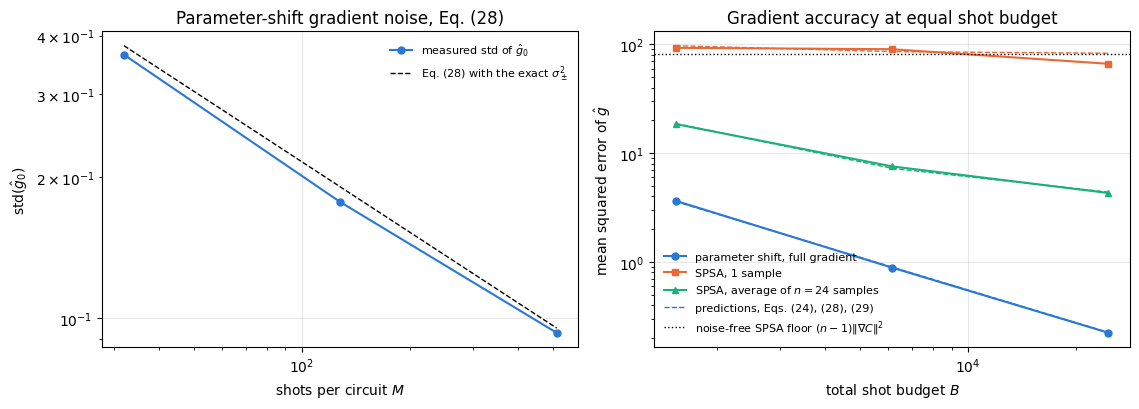

In [15]:
# ==============================================================================
# STEP 12: parameter-shift gradient with shot noise, and SPSA at equal shot budget
# ==============================================================================
n_sh = int(theta_sh.size)
cost_sh_exact = jax.jit(lambda t: cost_energy(t, terms_sh, N_SH, L_SH))
g_sh_exact = jax.grad(cost_sh_exact)(theta_sh)


def ps_grad_shots(key, theta, M):
    """Full parameter-shift gradient in which every circuit is estimated from M shots.

    COST  2 n circuits x M shots = 2 n M shots in total.
    JAX   vmap over the n unit vectors; each element draws its own pair of PRNG keys.
    """
    eye = jnp.eye(theta.size)
    k_plus, k_minus = jax.random.split(key)
    kp = jax.random.split(k_plus, theta.size)
    km = jax.random.split(k_minus, theta.size)

    def one(e, k1, k2):
        cp, _ = energy_shots(k1, hardware_efficient_ansatz(theta + (jnp.pi / 2) * e, N_SH, L_SH), M)
        cm, _ = energy_shots(k2, hardware_efficient_ansatz(theta - (jnp.pi / 2) * e, N_SH, L_SH), M)
        return (cp - cm) / 2

    return jax.vmap(one)(eye, kp, km)


def spsa_grad_shots(key, theta, M, c):
    """One SPSA sample in which both circuits are estimated from M shots.   COST 2 M shots in total."""
    kd, kp, km = jax.random.split(key, 3)
    delta = jax.random.rademacher(kd, theta.shape).astype(theta.dtype)
    cp, _ = energy_shots(kp, hardware_efficient_ansatz(theta + c * delta, N_SH, L_SH), M)
    cm, _ = energy_shots(km, hardware_efficient_ansatz(theta - c * delta, N_SH, L_SH), M)
    return (cp - cm) / (2 * c) * delta


# --- exact sigma^2 at every shifted angle vector, for the predictions of Eqs. (28) and (29) --------
eye_sh = jnp.eye(n_sh)
sig2_plus = np.asarray(jax.vmap(lambda e: sigma2_exact(hardware_efficient_ansatz(theta_sh + (jnp.pi / 2) * e,
                                                                                N_SH, L_SH)))(eye_sh))
sig2_minus = np.asarray(jax.vmap(lambda e: sigma2_exact(hardware_efficient_ansatz(theta_sh - (jnp.pi / 2) * e,
                                                                                 N_SH, L_SH)))(eye_sh))
grad2_sh = float(jnp.sum(g_sh_exact ** 2))
C_SPSA = 0.1

# --- (a) parameter-shift gradient noise versus shots per circuit ---------------------------
print(f"parameter-shift gradient, n = {n_sh} parameters, component k = 0")
print(f"{'M per circuit':>14s} {'total shots':>12s} {'measured std(g_0)':>19s} {'Eq.(28) std':>12s} {'ratio':>6s} "
      f"{'(mean-exact)/SEM':>17s}")
R2 = 200
ms_list = (32, 128, 512)
std_ps, pred_ps, ratios_g, z_g = [], [], [], []
for M in ms_list:
    ks = jax.random.split(jax.random.PRNGKey(41 + M), R2)
    G = jax.vmap(lambda k: ps_grad_shots(k, theta_sh, M))(ks)
    s0 = float(jnp.std(G[:, 0]))
    p0 = float(np.sqrt((sig2_plus[0] + sig2_minus[0]) / (4 * M)))
    z0 = (float(jnp.mean(G[:, 0])) - float(g_sh_exact[0])) / (s0 / np.sqrt(R2))
    std_ps.append(s0); pred_ps.append(p0); ratios_g.append(s0 / p0); z_g.append(z0)
    print(f"{M:14d} {2 * n_sh * M:12d} {s0:19.5f} {p0:12.5f} {s0 / p0:6.3f} {z0:17.2f}")
se_rg = 1.0 / np.sqrt(2 * R2) / np.sqrt(len(ms_list))
rg = float(np.mean(ratios_g))
rg_wrong = float(np.mean(np.array(ratios_g) / np.sqrt(2.0)))       # wrong: Var = (s+ + s-)/(2M), Eq. (28) without the 1/4
print(f"CHECKPOINT: max |z| = {np.max(np.abs(z_g)):.2f} (< 4);  mean std ratio = {rg:.3f} +- {se_rg:.3f} (within 4 SE of 1);"
      f"  wrong control (1/(2M) instead of 1/(4M)): {rg_wrong:.3f} (rejected)")
assert np.max(np.abs(z_g)) < 4 and abs(rg - 1) < 4 * se_rg and abs(rg_wrong - 1) > 4 * se_rg

# --- (b) equal-budget comparison: mean squared error of the FULL gradient vector ------------
print(f"\nequal shot budget B: parameter shift uses M = B/(2n) per circuit; SPSA (c = {C_SPSA}) uses M = B/2 per circuit")
print(f"{'budget B':>9s} | {'PS MSE':>8s} {'pred':>7s} | {'SPSA 1 sample':>13s} {'pred':>7s} | {'SPSA avg of n':>13s} {'pred':>7s}")
budgets = tuple(2 * n_sh * M for M in ms_list)
mse_ps, mse_spsa1, mse_spsan = [], [], []
pred_mse_ps, pred_mse_sp1, pred_mse_spn = [], [], []
z_mse = []
for B in budgets:
    M_ps = B // (2 * n_sh)
    ks = jax.random.split(jax.random.PRNGKey(51 + B), R2)
    G = jax.vmap(lambda k: ps_grad_shots(k, theta_sh, M_ps))(ks)
    sq = np.asarray(jnp.sum((G - g_sh_exact[None, :]) ** 2, axis=1))
    e_ps, pr_ps = float(sq.mean()), float(np.sum(sig2_plus + sig2_minus) / (4 * M_ps))
    z_mse.append((e_ps - pr_ps) / (sq.std() / np.sqrt(R2)))

    M_sp = B // 2
    ks = jax.random.split(jax.random.PRNGKey(61 + B), R2)
    Gs = jax.vmap(lambda k: spsa_grad_shots(k, theta_sh, M_sp, C_SPSA))(ks)
    e_sp1 = float(jnp.mean(jnp.sum((Gs - g_sh_exact[None, :]) ** 2, axis=1)))
    # Eq. (24) + n x Eq. (29); sigma^2 taken at theta (it changes little over a probe radius c = 0.1)
    pr_sp1 = (n_sh - 1) * grad2_sh + n_sh * sig2_sh / (2 * M_sp * C_SPSA ** 2)

    # same budget, spent as n SPSA samples of B/n shots each, then averaged
    M_spn = max(B // (2 * n_sh), 2)
    ks = jax.random.split(jax.random.PRNGKey(71 + B), R2 * n_sh).reshape(R2, n_sh, -1)
    Gn = jax.vmap(lambda kk: jnp.mean(jax.vmap(lambda k: spsa_grad_shots(k, theta_sh, M_spn, C_SPSA))(kk), axis=0))(ks)
    e_spn = float(jnp.mean(jnp.sum((Gn - g_sh_exact[None, :]) ** 2, axis=1)))
    pr_spn = ((n_sh - 1) * grad2_sh + n_sh * sig2_sh / (2 * M_spn * C_SPSA ** 2)) / n_sh

    mse_ps.append(e_ps); mse_spsa1.append(e_sp1); mse_spsan.append(e_spn)
    pred_mse_ps.append(pr_ps); pred_mse_sp1.append(pr_sp1); pred_mse_spn.append(pr_spn)
    print(f"{B:9d} | {e_ps:8.4f} {pr_ps:7.4f} | {e_sp1:13.3f} {pr_sp1:7.3f} | {e_spn:13.3f} {pr_spn:7.3f}")
print(f"CHECKPOINT: parameter-shift MSE vs prediction, max |z| = {np.max(np.abs(z_mse)):.2f} (< 4)")
assert np.max(np.abs(z_mse)) < 4

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
axes[0].loglog(ms_list, std_ps, "o-", ms=5, color=PALETTE[0], label=r"measured std of $\hat g_0$")
axes[0].loglog(ms_list, pred_ps, "k--", lw=1, label=r"Eq. (28) with the exact $\sigma^2_\pm$")
axes[0].set_xlabel("shots per circuit $M$"); axes[0].set_ylabel(r"std$(\hat g_0)$")
axes[0].set_title("Parameter-shift gradient noise, Eq. (28)"); axes[0].legend(fontsize=8)

axes[1].loglog(budgets, mse_ps, MARKERS[0] + "-", ms=5, color=PALETTE[0], label="parameter shift, full gradient")
axes[1].loglog(budgets, mse_spsa1, MARKERS[1] + "-", ms=5, color=PALETTE[1], label="SPSA, 1 sample")
axes[1].loglog(budgets, mse_spsan, MARKERS[2] + "-", ms=5, color=PALETTE[2], label=f"SPSA, average of $n={n_sh}$ samples")
for j, pr in enumerate((pred_mse_ps, pred_mse_sp1, pred_mse_spn)):
    axes[1].loglog(budgets, pr, "--", lw=1, color=PALETTE[j], label="predictions, Eqs. (24), (28), (29)" if j == 0 else None)
axes[1].axhline((n_sh - 1) * grad2_sh, color="k", ls=":", lw=1,
                label=r"noise-free SPSA floor $(n-1)\Vert\nabla C\Vert^2$")
axes[1].set_xlabel("total shot budget $B$")
axes[1].set_ylabel(r"mean squared error of $\hat{g}$")
axes[1].set_title("Gradient accuracy at equal shot budget"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

Two measured statements, both compared with parameter-free predictions built from the exact single-shot variances.

* **Left panel.** The parameter-shift estimator is unbiased at every shot budget (the mean of $200$ repetitions lies
  within two standard errors of the exact derivative), and its standard deviation follows Eq. (28): the measured to
  predicted ratio, averaged over the three budgets, is $0.95\pm0.03$. The wrong control, Eq. (28) with $1/(2M)$ in place
  of $1/(4M)$, is rejected.
* **Right panel.** At equal budget on this problem ($n=24$, $c=0.1$) the full parameter-shift gradient is the most
  accurate estimate, and its error falls as $1/B$, on the prediction $\sum_k(\sigma^2_{k+}+\sigma^2_{k-})/(4M)$ (checked
  to within one standard error). A single SPSA sample stays near the noise-free floor
  $(n-1)\lVert\nabla C\rVert^2$ of Eq. (24) at every budget: its shot-noise part, Eq. (29), is already the smaller
  term at $B=1536$, so buying more shots buys almost nothing. The single-sample values scatter by up to $20\,\%$ around
  the prediction, which is the sampling error of 200 repetitions of a heavy-tailed quantity. Averaging $n$ SPSA samples
  at the same total budget divides that floor by $n$ and lands on its prediction, between the other two curves.

On this problem, therefore, SPSA does not give a more accurate gradient for the same number of shots, as the scaling
argument of Section 12.3 predicts for $n<1/c^2$. Its case rests on *optimisation* rather than estimation: a noisy step
taken often can beat an accurate step taken rarely, and on hardware the cost per iteration may be dominated by the
number of distinct circuits rather than by shots. The next notebook measures that end-to-end comparison, where the
figure of merit is the cost reached per shot spent.

## 13. Barren plateaus

### 13.1 The phenomenon

For a *fixed* $n$ the landscape is a bounded trigonometric polynomial, so nothing about it is singular. The problem is
what happens to its **slope** as $N$ grows.

Two facts must be separated. First, for angles drawn uniformly from $[-\pi,\pi]^n$ the mean of every gradient component
vanishes, $\mathbb E_{\boldsymbol\theta}[\partial_kC]=0$, for *any* circuit of the type of Section 6: averaging over
$\theta_k$ alone gives $\frac1{2\pi}\int_{-\pi}^{\pi}\partial_kC\,d\theta_k=0$ because $C$ is $2\pi$-periodic in
$\theta_k$. A zero mean is therefore no sign of a plateau. Second, the **variance** $\mathrm{Var}_{\boldsymbol\theta}
[\partial_kC]$ measures how large the gradient typically is, and this is what can vanish exponentially with $N$.

McClean *et al.* (2018) computed it for random circuits in which the part before or after the differentiated gate (or
both) forms a unitary 2-design, i.e. reproduces the first two moments of Haar-random unitaries. For a circuit
$\cdots e^{-i\theta_kV}\cdots$ with both parts 2-designs, an observable $H$ and a pure input state, their result reads

$$\mathrm{Var}[\partial_kC]=2\,\mathrm{Tr}(H^2)\Bigl(\frac{\mathrm{Tr}(V^2)}{2^{3N}}-\frac{(\mathrm{Tr}V)^2}{2^{4N}}\Bigr).$$

The scaling depends on the observable through $\mathrm{Tr}(H^2)$ (only the traceless part of $H$ matters, because the
identity does not change any gradient). For a Pauli string, $\mathrm{Tr}(H^2)=2^N$ and, with $V=P/2$,
$\mathrm{Tr}(V^2)=2^N/4$, the variance is $2^{-N-1}$. For the projector cost of Eq. (9), $\mathrm{Tr}(\Pi_0^2)=1$, and it
is $\approx2^{-2N-1}$. Either way the gradient is **exponentially concentrated at zero**. A gradient must be resolved
above the shot noise, so an exponentially small gradient needs exponentially many shots (Exercise 8 makes this
quantitative, and finds a twist for the global cost).

Cerezo *et al.* (2021) showed that the *locality of the cost observable* matters as much as the depth. Their circuits
are alternating layered ansätze whose blocks form local 2-designs. For a **global** cost such as Eq. (9) the variance
vanishes exponentially in $N$ already for shallow circuits (their bound covers depths up to $O(\mathrm{poly}\log N)$,
and in particular depth $O(1)$). For a **local** cost such as Eq. (10) it vanishes at worst polynomially, as
$\Omega(1/\mathrm{poly}(N))$, as long as the depth is $O(\log N)$; for depth $O(\mathrm{poly}(N))$ the circuit
approaches a 2-design and the exponential decay returns for local costs too. The hardware-efficient ansatz of this
notebook ($R_yR_z$ rotations and a $CZ$ ladder) is not of their block form, so their theorems do not apply to it
literally; the measurement below tests whether it behaves the same way.

For the local cost at fixed depth there is a simple argument for the expected scaling. $\theta_0$ rotates qubit $0$ in
the first rotation block, and each $CZ$ layer spreads its influence by one site. With $L=2$ it reaches only
$\langle Z_0\rangle,\langle Z_1\rangle,\langle Z_2\rangle$, so $\partial_0C_{\text L}=\frac{1}{2N}\partial_0
\bigl(\langle Z_0\rangle+\langle Z_1\rangle+\langle Z_2\rangle\bigr)$, and the random variable in the bracket depends
only on the angles of qubits $0$ to $4$. For $N\ge5$ its distribution no longer depends on $N$, so
$\mathrm{Var}[\partial_0C_{\text L}]=\mathrm{const}/N^2$ exactly: a power law, with the $1/N^2$ coming from the
normalisation of Eq. (10).

### 13.2 Measuring it

The experiment is direct: draw $R$ parameter vectors uniformly from $[-\pi,\pi]^n$, compute one gradient component for
each, and take the sample variance. We do this for the global cost of Eq. (9) and the local cost of Eq. (10), at a
shallow depth ($L=2$, independent of $N$) and at a depth growing with the system ($L=N$). Each variance is quoted with
its standard error, $\mathrm{SE}[\widehat{\mathrm{Var}}]=\sqrt{(\hat\mu_4-\widehat{\mathrm{Var}}^2)/R}$ with $\hat\mu_4$ the
fourth central moment; for the global cost the distribution of $\partial_0C$ is strongly peaked with long tails, which
makes this error much larger than the Gaussian value $\widehat{\mathrm{Var}}\sqrt{2/R}$, and is the reason for the
large $R$.

The gradient component is obtained with the **parameter-shift rule** rather than `jax.grad`: two forward evaluations per draw,
no stored intermediates, so `vmap` over thousands of draws costs $O(2^N)$ memory per draw instead of $O(n_g\cdot2^N)$.

In [16]:
# ==============================================================================
# STEP 13: variance of one gradient component over random parameter draws
# ==============================================================================
R_DRAWS = 2000
N_LIST = (2, 4, 6, 8, 10)


def grad_component_samples(N, layers, cost_fn, n_draws=R_DRAWS, seed=0):
    """d C / d theta_0 at `n_draws` uniformly random angle vectors, by the two-term parameter-shift rule.

    JAX   one vmap over `n_draws` parameter vectors: 2 circuit evaluations each, no autodiff tape, O(2^N) memory per draw.
    """
    n = hea_num_params(N, layers)
    thetas = jax.random.uniform(jax.random.PRNGKey(seed), (n_draws, n), minval=-jnp.pi, maxval=jnp.pi)
    e0 = jnp.zeros(n).at[0].set(1.0)

    def one(t):
        return (cost_fn(t + (jnp.pi / 2) * e0, N, layers) - cost_fn(t - (jnp.pi / 2) * e0, N, layers)) / 2

    return np.asarray(jax.jit(jax.vmap(one))(thetas))


def var_with_error(g):
    """Sample variance and its standard error sqrt((mu_4 - Var^2)/R), valid for any (non-Gaussian) distribution."""
    d = g - g.mean()
    v = float(np.mean(d ** 2))
    return v, float(np.sqrt((np.mean(d ** 4) - v ** 2) / g.size))


print(f"{R_DRAWS} random parameter draws per point; Var of d C / d theta_0 with its standard error")
print(f"{'N':>3s} | {'L=2 global':>19s} {'L=2 local':>19s} | {'L=N global':>19s} {'L=N local':>19s} | "
      f"{'max |mean|/SEM':>14s}")
res = {k: [] for k in ("g2", "l2", "gN", "lN")}
err = {k: [] for k in ("g2", "l2", "gN", "lN")}
z_mean = []
for N in N_LIST:
    row = []
    for k, (L, cf) in (("g2", (2, cost_global)), ("l2", (2, cost_local)), ("gN", (N, cost_global)), ("lN", (N, cost_local))):
        g = grad_component_samples(N, L, cf)
        v, se = var_with_error(g)
        res[k].append(v); err[k].append(se); row.append(f"{v:9.3e}+-{se:7.1e}")
        z_mean.append(abs(g.mean()) / (g.std() / np.sqrt(g.size)))
    print(f"{N:3d} | {row[0]:>19s} {row[1]:>19s} | {row[2]:>19s} {row[3]:>19s} | {max(z_mean[-4:]):14.2f}")

# --- CHECKPOINT 1: zero mean (periodicity), tested on all 20 samples ----------------------------
print(f"\nmax over all points of |mean| / SEM = {max(z_mean):.2f}  (zero mean, Section 13.1; must be < 4)")
assert max(z_mean) < 4
# --- CHECKPOINT 2: local cost at L = 2 follows const / N^2 for N >= 5 (light-cone argument) -------
idx = [i for i, N in enumerate(N_LIST) if N >= 5]
for label, power in (("N^2 Var", 2), ("wrong control N^1 Var", 1)):
    vals = np.array([N_LIST[i] ** power * res["l2"][i] for i in idx])
    errs = np.array([N_LIST[i] ** power * err["l2"][i] for i in idx])
    w = 1 / errs ** 2
    chi2 = float(np.sum(w * (vals - np.sum(w * vals) / np.sum(w)) ** 2))
    print(f"local cost, L=2, N = {[N_LIST[i] for i in idx]}:  {label} = {np.round(vals, 5)}   chi^2 for a constant = "
          f"{chi2:.1f} with {len(idx) - 1} degrees of freedom")
    if power == 2:
        assert chi2 < 16            # P(chi^2_2 > 16) ~ 3e-4
    else:
        assert chi2 > 16            # the wrong scaling must be rejected

2000 random parameter draws per point; Var of d C / d theta_0 with its standard error
  N |          L=2 global           L=2 local |          L=N global           L=N local | max |mean|/SEM


  2 |  2.685e-02+-8.6e-04  1.859e-02+-5.3e-04 |  2.685e-02+-8.6e-04  1.859e-02+-5.3e-04 |           1.23


  4 |  2.793e-03+-1.6e-04  4.134e-03+-1.1e-04 |  2.148e-03+-1.1e-04  3.229e-03+-9.6e-05 |           1.02


  6 |  2.309e-04+-2.3e-05  1.805e-03+-4.7e-05 |  1.684e-04+-1.2e-05  9.609e-04+-2.9e-05 |           0.60


  8 |  2.107e-05+-2.6e-06  1.033e-03+-2.8e-05 |  1.109e-05+-1.1e-06  3.906e-04+-1.2e-05 |           1.22


 10 |  4.125e-06+-2.1e-06  6.613e-04+-1.9e-05 |  7.996e-07+-6.7e-08  2.089e-04+-6.8e-06 |           1.32

max over all points of |mean| / SEM = 1.32  (zero mean, Section 13.1; must be < 4)
local cost, L=2, N = [6, 8, 10]:  N^2 Var = [0.06498 0.0661  0.06613]   chi^2 for a constant = 0.3 with 2 degrees of freedom
local cost, L=2, N = [6, 8, 10]:  wrong control N^1 Var = [0.01083 0.00826 0.00661]   chi^2 for a constant = 158.5 with 2 degrees of freedom


exponential fit  log2 Var = alpha - beta N  over N = 2..10, and the LOCAL slopes between neighbouring N
        cost  beta (fit)    local slope -d log2 Var / dN  for N = 2-4, 4-6, 6-8, 8-10
 global, L=2        1.62     1.63    1.80    1.73    1.18
  local, L=2        0.58     1.08    0.60    0.40    0.32
 global, L=N        1.88     1.82    1.84    1.96    1.90
  local, L=N        0.80     1.26    0.87    0.65    0.45


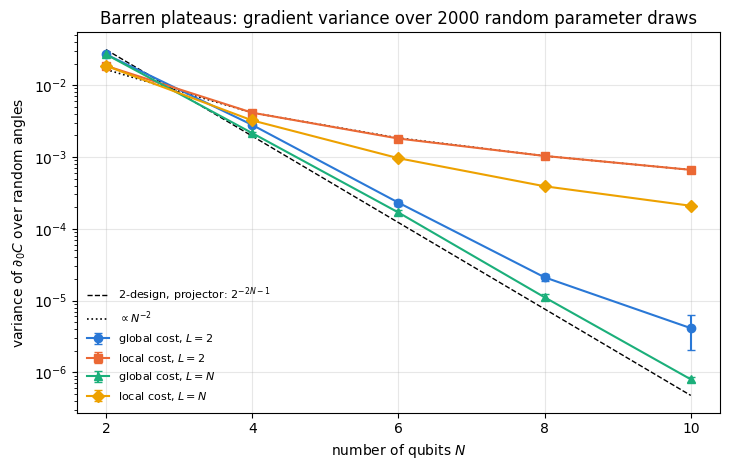


Var(local)/Var(global) at N = 10:  L=2: 160   L=N: 261


In [17]:
# ==============================================================================
# STEP 14: exponents and local slopes, and the plot
# ==============================================================================
Ns = np.array(N_LIST, dtype=float)
labels = {"g2": r"global cost, $L=2$", "l2": r"local cost, $L=2$",
          "gN": r"global cost, $L=N$", "lN": r"local cost, $L=N$"}
plain = {"g2": "global, L=2", "l2": "local, L=2", "gN": "global, L=N", "lN": "local, L=N"}
print("exponential fit  log2 Var = alpha - beta N  over N = 2..10, and the LOCAL slopes between neighbouring N")
print(f"{'cost':>12s} {'beta (fit)':>11s}   {'local slope -d log2 Var / dN  for N = 2-4, 4-6, 6-8, 8-10':>58s}")
fig, ax = plt.subplots(figsize=(7.4, 4.8))
for j, k in enumerate(("g2", "l2", "gN", "lN")):
    v, e = np.array(res[k]), np.array(err[k])
    beta = -np.polyfit(Ns, np.log2(v), 1)[0]
    slopes = -np.diff(np.log2(v)) / np.diff(Ns)
    print(f"{plain[k]:>12s} {beta:11.2f}   " + "  ".join(f"{x:6.2f}" for x in slopes))
    ax.errorbar(Ns, v, yerr=e, fmt=MARKERS[j] + "-", ms=6, color=PALETTE[j], capsize=3, label=labels[k])
ax.set_yscale("log")
ax.semilogy(Ns, 2.0 ** (-2 * Ns - 1), "k--", lw=1, label=r"2-design, projector: $2^{-2N-1}$")
ax.semilogy(Ns, res["l2"][-1] * (Ns[-1] / Ns) ** 2, "k:", lw=1.2, label=r"$\propto N^{-2}$")
ax.set_xlabel("number of qubits $N$"); ax.set_ylabel(r"variance of $\partial_0 C$ over random angles")
ax.set_xticks(Ns)
ax.set_title(f"Barren plateaus: gradient variance over {R_DRAWS} random parameter draws")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()
print(f"\nVar(local)/Var(global) at N = {N_LIST[-1]}:  L=2: {res['l2'][-1] / res['g2'][-1]:.0f}   "
      f"L=N: {res['lN'][-1] / res['gN'][-1]:.0f}")

**Reading the measurement.** All four curves fall with $N$, but in two different ways, and the local slopes
$-\Delta\log_2\mathrm{Var}/\Delta N$ between neighbouring sizes tell them apart better than one exponential fit.

* **Global cost, $L=N$.** The local slopes are $1.8$–$2.0$ at every $N$, and the points lie within a factor of two of the
  2-design value $2^{-2N-1}$ of Section 13.1 (dashed line). The deep circuit behaves like a random circuit for this
  observable, and the variance falls by more than four orders of magnitude from $N=2$ to $N=10$.
* **Global cost, $L=2$.** The variance falls almost as fast, with local slopes $1.6$–$1.8$ up to $N=8$ (the last slope,
  $1.2$, rests on the $N=10$ point, whose standard error is $50\,\%$ because a few draws dominate the variance). A shallow
  circuit does not protect a global cost: this is the behaviour Cerezo *et al.* prove for their layered circuits, and
  our different ansatz shows it too.
* **Local cost, $L=2$.** This curve is not exponential. Its local slope falls from $1.1$ to $0.3$ per qubit, and
  $N^2\,\mathrm{Var}$ is constant for $N\ge6$ (the checkpoint: $\chi^2=0.3$ for $2$ degrees of freedom, while the wrong
  scaling $N\,\mathrm{Var}$ gives $\chi^2=159$). That is the $1/N^2$ law derived from the light cone in Section 13.1: the
  gradient of a local cost at fixed depth sees only a fixed number of qubits, and the only $N$ dependence is the
  normalisation $1/N$ of Eq. (10). The fitted "exponent" $\beta=0.58$ of an exponential fit to these points has no
  meaning.
* **Local cost, $L=N$.** Deepening the circuit with $N$ steepens the decay (local slopes $1.3$, $0.9$, $0.65$, $0.45$),
  but over $N\le10$ the curve is not yet a clean exponential either; the light cone of a $CZ$ ladder grows by one site per
  layer, so at $L=N$ the circuit has only just reached the far end of the chain. Where the circuit approaches a 2-design,
  Cerezo *et al.* predict exponential decay for local costs too; these sizes cannot establish the asymptotic rate.

At $N=10$ the local cost has a gradient variance $160$ times larger than the global cost of the same circuit at the same
random angles for $L=2$, and $260$ times larger for $L=N$.

The mean gradient is zero within $1.3$ standard errors at every point, as the periodicity argument of Section 13.1
requires for any circuit; it carries no information about the plateau. The information is in the variance: the typical
gradient magnitude $\sqrt{\mathrm{Var}}$ is what has to be resolved above the shot noise.

### 13.3 Mitigation strategies

The list contains only what this notebook demonstrates, or what is quoted with a reference:

* **Use a local cost.** Demonstrated above: at $L=2$ the local cost of Eq. (10) decays as $N^{-2}$, the global cost of
  Eq. (9) exponentially, for the same circuit and the same random angles. Both have the same minimiser (Section 5.3).
  (Cerezo *et al.*, 2021.)
* **Keep the circuit shallow.** Demonstrated above for the local cost: at $L=N$ it decays faster than at $L=2$. Cerezo
  *et al.* prove that for local costs a depth $O(\log N)$ keeps the variance at worst polynomially small. For the global
  cost, depth does not help much: $L=2$ is already close to $L=N$.
* **Use a problem-inspired ansatz.** Not measured here (Exercise 7 does it). The Hamiltonian-variational ansatz of
  Section 4.2 has $2L$ shared parameters and a structure tied to the target; ansatz design as a mitigation is reviewed
  in Cerezo *et al.* (2021, *Nature Reviews Physics*).
* **Initialise with structure rather than uniformly.** Not measured here. The variance above was taken over the
  *uniform* distribution on $[-\pi,\pi]^n$. Initialisations that start near the identity, or that grow the circuit layer
  by layer, sample a different distribution; this is reviewed in Cerezo *et al.* (2021, *Nature Reviews Physics*).

> **Common pitfall.** A barren plateau cannot be fixed by a better optimiser. On hardware every method of this notebook
> has to resolve $\partial_kC$ above the shot noise, and an exponentially small quantity requires exponentially many
> shots however it is estimated. The remedy has to change the *cost*, the *ansatz* or the *initialisation*.

## 14. Key takeaways

* **A variational quantum algorithm is a hybrid loop**: a parametrized circuit prepares $\vert\psi(\boldsymbol\theta)
  \rangle$, a measurement returns a cost, a classical optimiser proposes new angles. The quantum part is deliberately
  short, which is why the framework targets present-day noisy hardware.
* **Parametrized gates are Pauli exponentials.** $P^2=\mathbb 1$ collapses the exponential series to
  $\cos\tfrac\theta2\,\mathbb 1-i\sin\tfrac\theta2\,P$, Eq. (2), for one-qubit and two-qubit Pauli rotations alike. A
  controlled rotation is also an exponential, but of a generator with eigenvalues $\{0,0,\pm\tfrac12\}$, three distinct
  values, and therefore needs a different gradient rule.
* **Ansatz design is a choice between two philosophies.** Hardware-efficient: $2N(L+1)$ angles, native gates, no physics
  input, and (Section 13) exposure to barren plateaus. Hamiltonian-variational: $2L$ shared angles independent of $N$,
  descended from Trotterised adiabatic evolution, and containing the adiabatic path for large enough $L$.
* **The cost along one angle is $a+b\cos(\theta-c)$, exactly,** when the angle enters a single gate
  $e^{-i\theta P/2}$ with $P^2=\mathbb 1$. The derivation is two projectors and a Hermiticity argument, Eq. (12); the
  three-parameter fit left a residual of $10^{-15}$, while the same fit on a shared angle failed.
* **Four gradients, measured.** Finite differences: error bottoming out near $h_\star\approx10^{-5}$, where Eq. (16)
  with $\lvert C'''\rvert=\lvert C'\rvert$ puts it, about five of sixteen digits lost, and nearly five orders of
  magnitude short of parameter shift at every parameter count. Parameter shift: exact, $10^{-15}$ at every parameter
  count, $2n$ circuit evaluations, and a four-term generalisation, Eq. (19), that is needed and verified for controlled
  rotations, where the two-term rule is wrong by $0.2$. SPSA: mean equal to the gradient up to the $c^2\beta_k$ term of
  Eq. (22), verified at $c=0.2$, variance $\lVert\nabla C\rVert^2-(\partial_kC)^2$ for $c\lesssim0.05$, and an expansion
  that breaks down at $c=0.5$ for $n=40$. Reverse-mode AD: machine precision, about three forward passes for all
  $72$ derivatives at $N=12$, and reproduced by a hand-written adjoint differentiator.
* **`vmap` is worth about an order of magnitude here, and it is not free.** The identical parameter-shift formula runs
  roughly ten times faster when the $2n$ shifted circuits are batched into one XLA program, and the measured scratch
  allocation is $76$ times that of a single forward pass, because eighty circuits are in flight at once.
* **Memory is the reverse-mode tax.** Storing intermediates costs $O(n_g\cdot2^N)$: the measured scratch of `jax.grad`
  was six times a forward pass; the adjoint trick, recomputing $\vert\psi_{l-1}\rangle=U_l^\dagger\vert\psi_l\rangle$
  instead of storing it, brought it down to $1.7$ times a forward pass, the $O(2^N)$ it was designed for.
* **Shot noise costs $M^{-1/2}$ everywhere, with prefactors that can be computed.** The parameter-shift estimator is
  unbiased and its noise obeys Eq. (28) with the exact single-shot variances; at equal shot budget, for $n=24$ and
  $c=0.1$, the full parameter-shift gradient is more accurate than SPSA, single or averaged, as $n<1/c^2$ predicts.
* **Barren plateaus are measurable.** Over uniformly random angles, the variance of one gradient component of the global
  cost falls by a factor of three to four per added qubit, already at $L=2$, and close to the 2-design value $2^{-2N-1}$ at
  $L=N$. The local cost at $L=2$ falls only as $N^{-2}$, as the light-cone argument predicts: the cost-locality effect
  of Cerezo *et al.*, measured rather than quoted. The mean gradient is zero in every case, as periodicity requires.

## 15. Exercises

1. ★ **Read the sinusoid.** For the circuit of Section 6, extract $a$, $b$ and $c$ from the fit and verify the two
   parameter-shift identities directly: $C(\theta+\tfrac\pi2)-C(\theta-\tfrac\pi2)=2C'(\theta)$, and
   $C(\theta+\pi)+C(\theta)=2a$. What does the second identity give you that the gradient does not? Use the three
   numbers $C(\theta)$, $C(\theta\pm\tfrac\pi2)$ to locate the exact minimum of the cut.
2. ★ **The optimal finite-difference step in single precision.** Rerun the notebook with `PRECISION = "single"` in the
   Configuration cell (the random angles change, because they are drawn in the working precision). Predict $h_\star$
   and the achievable accuracy from Eq. (16) and the formula for $E(h_\star)$ with
   $\varepsilon_{\text m}\approx1.2\cdot10^{-7}$ before you run it, then compare. Which of the later results of the
   notebook change visibly?
3. ★★ **A two-qubit rotation ansatz (extend the code).** Replace the fixed $CZ$ entanglers of the hardware-efficient
   ansatz by parametrized $R_{ZZ}(\theta)$ gates. Count the new parameters, check that the two-term parameter-shift rule
   still applies (what is the generator's spectrum?), and verify it against `jax.grad`.
4. ★★ **The four-term parameter-shift rule.** Derive the analogue of Eq. (19) for a cost whose frequencies in $\theta$ are
   $\{1,2\}$, for instance one angle shared by two gates $R_z(\theta)\otimes R_z(\theta)$, i.e.
   $e^{-i\theta(Z_1+Z_2)/2}$ with generator eigenvalues $\{-1,0,0,1\}$. Verify it numerically on a two-qubit circuit,
   and show that the two-term rule fails there. How many evaluations per parameter does it need?
5. ★★ **SPSA with Gaussian directions (extend the code).** Replace the Rademacher $\boldsymbol\Delta$ by a standard
   Gaussian one and use $1/\Delta_k$ in Eq. (20). Show analytically that $\mathbb E[\lvert1/\Delta_k\rvert]$ and
   $\mathbb E[1/\Delta_k^2]$ diverge, measure what that does to the sample mean and the sample variance of the estimator
   as the number of samples grows, and explain why the finite-inverse-moment condition on the perturbation distribution
   in Spall's convergence theory excludes the Gaussian (Spall, 1998).
6. ★★ **Cost of the adjoint method (extend the code).** Instrument `adjoint_gradient` to count gate applications, and
   verify the count $3n_g+n$ (plus one Hamiltonian application) of Section 10.1 for the circuit of Section 10. Then jit
   it, compare its run time and its compile time with `jax.grad` for $N=4,6,8,10,12$ at fixed $L$, and comment.
7. ★★★ **Barren plateaus with a problem-inspired ansatz (physics).** Repeat the scan of Section 13 with the
   Hamiltonian-variational ansatz of Section 4.2 and the TFIM energy per site, $C/N$, as the cost (the energy is
   extensive, so divide by $N$ to compare with the local cost). Use $L=2$ and $L=8$ and differentiate with respect to
   $\gamma_1$ (with `jax.grad`, since the angles are shared and the two-term rule does not apply). Does the gradient
   variance decay exponentially in $N$ for $N\le10$?
8. ★★★ **The shot budget that a plateau demands (physics).** Combine Sections 12 and 13: for the global cost at
   $L=2$, estimate how many shots per circuit are needed for the parameter-shift gradient's standard deviation,
   Eq. (28), to fall below the typical gradient magnitude $\sqrt{\mathrm{Var}[\partial_0C]}$, and plot that budget
   against $N$. The global cost is measured with one setting, and a single shot is a Bernoulli variable, so
   $\sigma^2=p_0(1-p_0)$ with $p_0=\lvert\langle0^{\otimes N}\vert\psi\rangle\rvert^2$; measure the average of
   $\sigma^2$ over the random angles rather than assuming it is of order one. How fast does the budget grow with $N$,
   and at which $N$ does a full gradient ($2n$ circuits) exceed $10^9$ shots, roughly a day at $10^4$ shots per second?

## References

* A. Peruzzo, J. McClean, P. Shadbolt, M.-H. Yung, X.-Q. Zhou, P. J. Love, A. Aspuru-Guzik and J. L. O'Brien,
  *A variational eigenvalue solver on a photonic quantum processor*, Nat. Commun. **5**, 4213 (2014) — the first
  variational quantum eigensolver experiment (two qubits, HeH$^+$).
* J. R. McClean, J. Romero, R. Babbush and A. Aspuru-Guzik, *The theory of variational hybrid quantum-classical
  algorithms*, New J. Phys. **18**, 023023 (2016) — the general framework of the hybrid loop of Section 1.
* A. Kandala, A. Mezzacapo, K. Temme, M. Takita, M. Brink, J. M. Chow and J. M. Gambetta, *Hardware-efficient
  variational quantum eigensolver for small molecules and quantum magnets*, Nature **549**, 242 (2017) — the
  hardware-efficient ansatz of Section 4.1 (Euler rotations and native cross-resonance entanglers).
* K. Mitarai, M. Negoro, M. Kitagawa and K. Fujii, *Quantum circuit learning*, Phys. Rev. A **98**, 032309 (2018) —
  the parameter-shift rule for Pauli-generated gates.
* M. Schuld, V. Bergholm, C. Gogolin, J. Izaac and N. Killoran, *Evaluating analytic gradients on quantum hardware*,
  Phys. Rev. A **99**, 032331 (2019) — the shift rule for every generator with two eigenvalues $\pm r$, and an
  ancilla-based method for other gates.
* A. Mari, T. R. Bromley and N. Killoran, *Estimating the gradient and higher-order derivatives on quantum hardware*,
  Phys. Rev. A **103**, 012405 (2021) — the arbitrary-shift rule of Eq. (17), and the shot-noise comparison of parameter
  shift with finite differences.
* G.-L. R. Anselmetti, D. Wierichs, C. Gogolin and R. M. Parrish, *Local, expressive, quantum-number-preserving VQE
  ansätze for fermionic systems*, New J. Phys. **23**, 113010 (2021) — the four-term shift rule of Eq. (19), with the
  shifts $\pi/2$, $3\pi/2$ and the coefficients $(\sqrt2\pm1)/(4\sqrt2)$ (Appendix F of the paper).
* D. Wierichs, J. Izaac, C. Wang and C. Y.-Y. Lin, *General parameter-shift rules for quantum gradients*,
  Quantum **6**, 677 (2022) — the general rule with $2R$ evaluations for $R$ frequencies, which contains Eq. (19) as
  the case $R=2$.
* J. C. Spall, *Multivariate stochastic approximation using a simultaneous perturbation gradient approximation*,
  IEEE Trans. Autom. Control **37**, 332 (1992) — SPSA, the $O(c^2)$ bias of its gradient estimate and its convergence
  theory.
* J. C. Spall, *An overview of the simultaneous perturbation method for efficient optimization*, Johns Hopkins APL
  Tech. Dig. **19**, 482 (1998) — the conditions on the perturbation distribution, and why Gaussian and uniform
  perturbations are excluded.
* T. Jones and J. Gacon, *Efficient calculation of gradients in classical simulations of variational quantum
  algorithms*, arXiv:2009.02823 (2020) — a derivation of the adjoint-differentiation method of Section 10.2 for
  state-vector simulators, in $O(n)$ time for $n$ parameters and with $O(1)$ state vectors.
* J. R. McClean, S. Boixo, V. N. Smelyanskiy, R. Babbush and H. Neven, *Barren plateaus in quantum neural network
  training landscapes*, Nat. Commun. **9**, 4812 (2018) — the 2-design variance formula of Section 13.1.
* M. Cerezo, A. Sone, T. Volkoff, L. Cincio and P. J. Coles, *Cost function dependent barren plateaus in shallow
  parametrized quantum circuits*, Nat. Commun. **12**, 1791 (2021) — global versus local cost functions.
* M. Cerezo, A. Arrasmith, R. Babbush, S. C. Benjamin, S. Endo, K. Fujii, J. R. McClean, K. Mitarai, X. Yuan,
  L. Cincio and P. J. Coles, *Variational quantum algorithms*, Nat. Rev. Phys. **3**, 625 (2021) — the review of the
  whole field, including ansatz design and plateau mitigation.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/